# Axion Monodromy Simulation

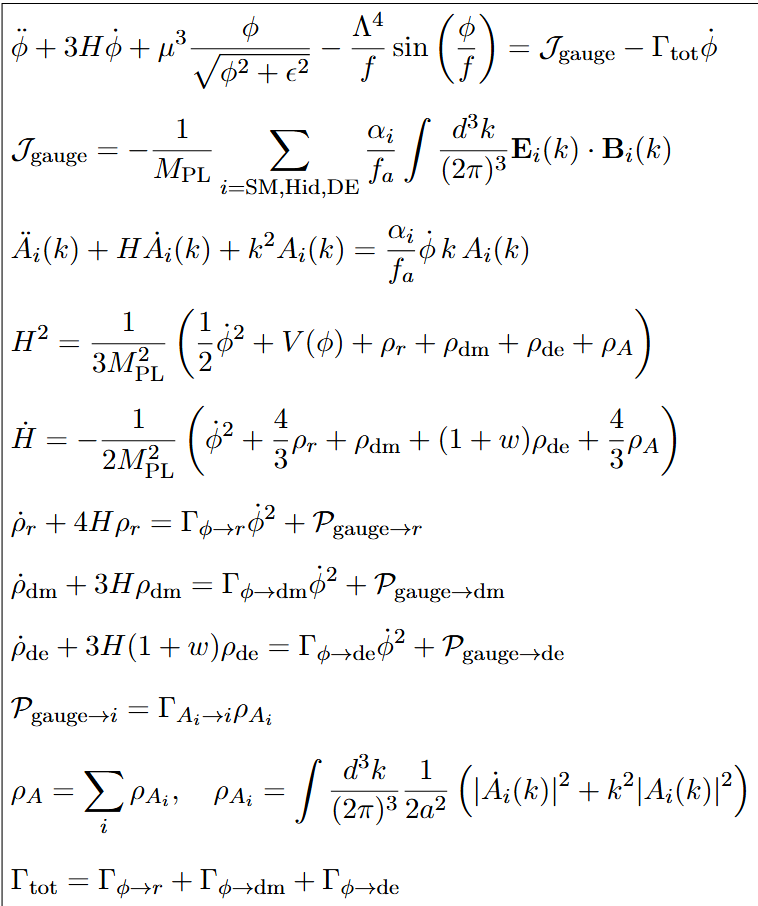

Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
from scipy.special import zeta
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import matplotlib.pyplot as plt
from numba import njit
import pickle
import pandas as pd
import csv
import os
from scipy.interpolate import interp1d
from scipy.integrate import simpson as simps

Define Constants

In [ ]:
g_star = 100

Equations

In [ ]:
def axionPotential(mu, phi, Lambda, fa, epsilon):
    linear_like = mu**3 * np.sqrt(phi**2 + epsilon**2)
    oscillations = Lambda**4 * (1.0 - np.cos(phi / fa))

    return linear_like + oscillations
@njit
def dVdphi(mu, phi, Lambda, fa, epsilon):
    # Linear term derivative
    if abs(phi) > 1e-10:
        dV_linear = mu**3 * phi / np.sqrt(phi**2 + epsilon**2)
    else:
        dV_linear = mu**3 * phi / epsilon  # Regularized

    # Oscillation term derivative: d/dφ [Λ⁴(1 - cos(φ/f))] = (Λ⁴/f) sin(φ/f)
    dV_osc = (Lambda**4 / fa) * np.sin(phi / fa)

    return dV_linear + dV_osc

@njit
def wde(a, w0=-0.971, wa=-0.62):
    return w0 + wa * (1 - a)

@njit
def compute_H(phi, phi_dot, rho_r, rho_dm, rho_de, rho_A, mu, Lambda, fa, epsilon):
    V_phi = axionPotential(mu, phi, Lambda, fa, epsilon)
    rho_phi = 0.5 * phi_dot**2 + V_phi
    rho_total = rho_phi + rho_r + rho_dm + rho_de + rho_A

    if rho_total <= 0:
        return 1e-30

    H = np.sqrt(rho_total / 3.0)  # M_pl = 1

    if H < 1e-30:
        return 1e-30
    elif H > 1e20:
        return 1e20
    else:
        return H
@njit
def compute_rho_A(A, A_dot, k, a):

    a_safe = max(a, 1e-30)
    energy = (A_dot**2 + k**2 * A**2) / (2 * a_safe**4)

    return energy
@njit
def compute_J_gauge(A, A_dot, k, alpha, fa, M_pl):

    # A and A_dot are rescaled variables
    E_dot_B = - (k * A * A_dot) / max(a**4, 1e-120)
    return - (1/M_pl)*(alpha / (fa * M_pl)) * E_dot_B

def bd_initial_conditions(k, a_start, H_start):
    # For numerical stability
    k_safe = max(k, 1e-30)
    a_safe = max(a_start, 1e-30)

    # Physical momentum at horizon crossing for this mode
    # Not used directly but for reference
    k_horizon_crossing = a_safe * H_start

    # Simple approach: initialize with frozen super-horizon approximation
    # The exact initial conditions don't matter much as long as they're small
    # and the equations will evolve them correctly once instability kicks in

    # Quantum vacuum amplitude in physical units
    # δA ~ H/(2π) is the typical vacuum fluctuation amplitude
    quantum_amp_physical = H_start / (2*np.pi)

    # Convert to rescaled variable: A_rescaled = a × A_physical
    A_rescaled = a_safe * quantum_amp_physical

    # Add k-dependence: 1/√k scaling from BD vacuum
    # But for numerical stability, don't let it get too small
    k_factor = 1.0 / np.sqrt(max(k_safe / (a_safe * H_start), 1.0))
    A_rescaled *= k_factor

    # Random phase (doesn't matter much but more physical)
    phase = np.random.uniform(0, 2*np.pi)
    A_rescaled *= -np.cos(phase)

    # Frozen super-horizon: Ȧ ≈ HA
    A_dot_rescaled = H_start * A_rescaled

    # Ensure reasonable numerical range
    # Avoid values < 1e-30 or > 1e10
    A_rescaled = np.clip(A_rescaled, -1e-10, 1e-10)
    A_dot_rescaled = np.clip(A_dot_rescaled, -1e-5, 1e-5)

    return A_rescaled, A_dot_rescaled
def init_mode_bank(k_array, a_start, H_start):
    """Initialize gauge fields with BD vacuum."""
    n_k = len(k_array)
    A0 = np.zeros(n_k)
    A_dot0 = np.zeros(n_k)

    for i, k in enumerate(k_array):
        A0[i], A_dot0[i] = bd_initial_conditions(k, a_start, H_start)

    return A0, A_dot0
def make_k_grid(k_min, k_max, n_k, spacing='log'):
    """Return array of k values"""
    if spacing == 'log':
        return np.exp(np.linspace(np.log(k_min), np.log(k_max), n_k))
    else:
        return np.linspace(k_min, k_max, n_k)
def compute_H_nonjit(phi, phi_dot, rho_r, rho_dm, rho_de, rho_A, mu, Lambda, fa, epsilon):
    """Non-JIT version for use in analysis/plotting code"""
    V_phi = axionPotential(mu, phi, Lambda, fa, epsilon)
    rho_phi = 0.5 * phi_dot**2 + V_phi
    rho_total = rho_phi + rho_r + rho_dm + rho_de + rho_A

    if rho_total <= 0:
        return 1e-30

    H = np.sqrt(rho_total / 3.0)

    return np.clip(H, 1e-30, 1e20)

Trapezoid Rule

In [ ]:
def init_integration_weights(k_array):
    n = len(k_array)
    weights = np.zeros(n)

    if n == 1:
        weights[0] = 1.0  # Single point case
    elif n == 2:
        # Two points: simple average
        weights[0] = weights[1] = 0.5 * (k_array[1] - k_array[0])
    else:
        # First point
        weights[0] = 0.5 * (k_array[1] - k_array[0])
        # Last point
        weights[-1] = 0.5 * (k_array[-1] - k_array[-2])
        # Middle points
        for i in range(1, n-1):
            weights[i] = 0.5 * (k_array[i+1] - k_array[i-1])

    return weights

Energy Conservation check

In [ ]:
def check_energy_conservation(y, params, N):
    phi, phi_dot, rho_r, rho_dm, rho_de, a, H = y[0], y[1], y[2], y[3], y[4], y[5], y[6]

    mu = params['mu']; Lambda = params['Lambda']; fa = params['fa']; epsilon = params['epsilon']

    # Calculate total energy from components
    V_phi = axionPotential(mu, phi, Lambda, fa, epsilon)
    rho_phi = 0.5 * phi_dot**2 + V_phi

    # Sum over gauge fields
    n_k = len(params['k_array'])
    integration_weights = params['integration_weights']
    rho_A_total = 0.0
    for i in range(n_k):
        A_idx = 7 + 2*i
        A_dot_idx = 7 + 2*i + 1
        k_val = params['k_array'][i]
        rho_A_total += compute_rho_A(y[A_idx], y[A_dot_idx], k_val, a) * integration_weights[i]
    total_energy_components = rho_phi + rho_r + rho_dm + rho_de + rho_A_total

    total_energy_Hubble = 3.0 * H**2

    if total_energy_Hubble <= 0:
        return 0.0

    violation = abs(total_energy_components - total_energy_Hubble) / total_energy_Hubble

    if violation > 0.01:  # More than 1% violation
        print(f"ENERGY VIOLATION at N={N:.3f}: {violation:.2e}")
        print(f"  Components: {total_energy_components:.2e}, Hubble: {total_energy_Hubble:.2e}")
        print(f"  Breakdown: ρ_ϕ={rho_phi:.2e}, ρ_r={rho_r:.2e}, ρ_dm={rho_dm:.2e}, ρ_de={rho_de:.2e}, ρ_A={rho_A_total:.2e}")

    return violation


Full System

In [ ]:
def full_system_multik(N, y, params):
    try:
        # Unpack with bounds
        phi = np.clip(y[0], -1e10, 1e10)
        phi_dot = np.clip(y[1], -1e15, 1e15)
        rho_r = max(y[2], 1e-60)
        rho_dm = max(y[3], 1e-60)
        rho_de = max(y[4], 1e-60)
        a = max(y[5], 1e-30)
        H = max(y[6], 1e-30)

        k_array = params['k_array']
        alpha = params['alpha']
        fa = params['fa']
        mu = params['mu']; Lambda = params['Lambda']; epsilon = params['epsilon']
        integration_weights = params['integration_weights']
        n_k = len(k_array)

        # Unpack gauge fields with bounds
        A = np.clip(y[7:7+2*n_k:2], -1e-5, 1e-5)
        A_dot = np.clip(y[8:7+2*n_k:2], -1e-8, 1e-8)
        # Compute per-mode quantities
        rho_A_k = np.zeros(n_k)
        E_dot_B_k = np.zeros(n_k)
        for i, k in enumerate(k_array):
            rho_A_k[i] = compute_rho_A(A[i], A_dot[i], k, a)
            E_dot_B_k[i] = - (k * A[i] * A_dot[i]) / max(a**4, 1e-120)  # 1/a⁴
        # Safe integration
        if len(k_array) > 1:
            rho_A_total = np.sum(rho_A_k * integration_weights)
            E_dot_B_total = np.sum(E_dot_B_k * integration_weights)
        else:
            rho_A_total = rho_A_k[0]
            E_dot_B_total = E_dot_B_k[0]
        # Get decay rates
        Gamma_phi_r = params.get('Gamma_phi_r', 0.0)
        Gamma_phi_dm = params.get('Gamma_phi_dm', 0.0)
        Gamma_phi_de = params.get('Gamma_phi_de', 0.0)

        # Inflaton energy with bounds
        V_phi = axionPotential(mu, phi, Lambda, fa, epsilon)
        rho_phi = 0.5 * phi_dot**2 + V_phi
        # Decay terms with bounds
        decay_phi_to_r = min(Gamma_phi_r * rho_phi, 1e50)
        decay_phi_to_dm = min(Gamma_phi_dm * rho_phi, 1e50)
        decay_phi_to_de = min(Gamma_phi_de * rho_phi, 1e50)

        # Gauge field decay terms
        Gamma_A_SM_r = params.get('Gamma_A_SM_r', 0.0)
        Gamma_A_Hid_dm = params.get('Gamma_A_Hid_dm', 0.0)
        Gamma_A_DE_de = params.get('Gamma_A_DE_de', 0.0)

        decay_A_to_r = min(Gamma_A_SM_r * rho_A_total, 1e50)
        decay_A_to_dm = min(Gamma_A_Hid_dm * rho_A_total, 1e50)
        decay_A_to_de = min(Gamma_A_DE_de * rho_A_total, 1e50)

        # Gauge backreaction current
        J_gauge_total = - (alpha / fa) * E_dot_B_total  # M_pl = 1
        J_gauge_total = np.clip(J_gauge_total, -1e20, 1e20)

        # Inflaton equations
        dV = dVdphi(mu, phi, Lambda, fa, epsilon)
        Gamma_tot = Gamma_phi_r + Gamma_phi_dm + Gamma_phi_de

        phi_prime = phi_dot / H
        phi_dot_prime = (-(3.0 * H + Gamma_tot) * phi_dot - dV + J_gauge_total) / H

        # Energy density equations
        rho_r_prime = (-4.0 * H * rho_r + decay_phi_to_r + decay_A_to_r) / H
        rho_dm_prime = (-3.0 * H * rho_dm + decay_phi_to_dm + decay_A_to_dm) / H

        w = wde(a)
        rho_de_prime = (-3.0 * H * (1.0 + w) * rho_de + decay_phi_to_de + decay_A_to_de) / H

        # Scale factor
        a_prime = a

        # Hubble equation
        H_dot = -0.5 * (phi_dot**2 + (4/3)*rho_r + rho_dm + (1+w)*rho_de + (4/3)*rho_A_total)
        H_prime = H_dot / H if H > 1e-30 else 0.0

        # Gauge field mode equations
        dA = np.zeros(n_k)
        dA_dot = np.zeros(n_k)
        for i, k in enumerate(k_array):
            # Equation for A (rescaled)
            dA[i] = A_dot[i] / H

            # Equation for A_dot (rescaled)
            source_term = (alpha / fa) * phi_dot * k * A[i] / a**2  # /a² for rescaled
            mass_term = - (k**2 / a**2) * A[i]  # /a² for rescaled
            damping = -2.0 * H * A_dot[i]  # Natural damping in rescaled vars

            dA_dot[i] = (damping + mass_term + source_term) / H

            # Apply reasonable bounds
            dA_dot[i] = np.clip(dA_dot[i], -1e-5 * H, 1e-5 * H)

        # Return derivatives
        dydN = [phi_prime, phi_dot_prime, rho_r_prime, rho_dm_prime, rho_de_prime, a_prime, H_prime]
        for i in range(n_k):
            dydN.extend([dA[i], dA_dot[i]])

        return np.array(dydN)

    except Exception as e:
        print(f"Error in full_system_multik at N={N}: {e}")
        return np.zeros_like(y)


In [ ]:
def save_simulation(sol, filename="simulation_checkpoint.pkl"):
    with open(filename, 'wb') as f:
        pickle.dump({
            't': sol.t,
            'y': sol.y,
            'success': sol.success,
            'message': sol.message,
            'nfev': sol.nfev
        }, f)
    print(f"Simulation saved to {filename}")

def load_simulation(filename="simulation_checkpoint.pkl"):
    if os.path.exists(filename):
        with open(filename, 'rb') as f:
            data = pickle.load(f)

        sol = type('', (), {})()
        sol.t = data['t']
        sol.y = data['y']
        sol.success = data.get('success', True)
        sol.message = data.get('message', "")
        sol.nfev = data.get('nfev', None)

        # Attach multi-k additions
        sol.k_array = data.get('k_array', None)
        sol.params = data.get('params', None)

        print(f"Simulation loaded from {filename}")
        return sol
    else:
        print(f"No checkpoint found at {filename}")
        return None

Run Simulation of Inflation + Post-Inflation Era

In [ ]:
def run_multi_k_simulation(N_final, n_k,
        k_min=1e-8, k_max=1e1,
        a_start=1e-30,
        phi0=None, phi_dot0=None,
        params_extra=None,
        checkpoint_file="multi_k_checkpoint.pkl",
        resume=False,
        checkpoint_interval=0.01):
    # ========== PARAMETERS ==========
    M_pl_fix = 1.0  # In Planck units
    energy_scale = 2.4e18  # GeV per Planck unit

    # String theory parameters
    g_s = 0.1
    CY_volume = 1e14
    cycle_volume = 1000

    # Derived scales
    M_string = 1.0 / np.sqrt(CY_volume)  # ~1e-7
    fa_fix = 0.05

    # Chern-Simons couplings
    n_SM, n_Hid, n_DE = 1, 1, 1
    alpha_fix = 0.01

    # Potential parameters
    Lambda_fix = 1e-5
    mu_fix = 1e-4
    epsilon_fix = 1e-10
    # Decay rates
    Gamma_phi_r_fix = 1e-10
    Gamma_phi_dm_fix = 1e-12
    Gamma_phi_de_fix = 1e-14

    Gamma_tot_fix = Gamma_phi_r_fix + Gamma_phi_dm_fix + Gamma_phi_de_fix
    Gamma_A_SM_r_fix = Gamma_phi_r_fix
    Gamma_A_Hid_dm_fix = Gamma_phi_dm_fix
    Gamma_A_DE_de_fix = Gamma_phi_de_fix

    if phi0 == None:
        phi0 = 1.0
    if phi_dot0 == None:
        phi_dot0 = -1e-6
    a_start = 1e-30

    # Initial densities
    H_start_initial = np.sqrt(mu_fix**3 * phi0 / 3.0)
    rho_total_initial_fix = 3 * H_start_initial**2
    rho_r_initial_fix = 1e-30 * rho_total_initial_fix
    rho_dm_initial_fix = 1e-35 * rho_total_initial_fix
    rho_de_initial_fix = 1e-35 * rho_total_initial_fix

    # -----------------------
    # Resume from checkpoint if requested
    # -----------------------
    if resume:
        print(f"Attempting to resume from {checkpoint_file}")
        try:
            with open(checkpoint_file, 'rb') as f:
                checkpoint_data = pickle.load(f)

            # Extract state from checkpoint
            t_previous = checkpoint_data['t']
            y_previous = checkpoint_data['y']
            params = checkpoint_data['params']
            k_array = checkpoint_data['k_array']
            H_previous = checkpoint_data.get('H', None)
            if 'integration_weights' not in params:
                print("Computing missing integration_weights...")
                params['integration_weights'] = init_integration_weights(k_array)

            # Start from last saved point
            t_start = t_previous[-1]
            y0 = y_previous[:, -1] if y_previous.ndim > 1 else y_previous

            print(f"Resumed from N={t_start:.3f}, continuing to N={N_final}")

            # Set up for chunked integration
            all_t = list(t_previous)
            all_y = [y_previous[:, i] for i in range(len(t_previous))] if y_previous.ndim > 1 else [y_previous]
            all_H = list(H_previous) if H_previous is not None else []

        except Exception as e:
            print(f"Failed to load checkpoint: {e}")
            print("Starting fresh simulation")
            resume = False

    if not resume:
        k_array = np.exp(np.linspace(np.log(k_min), np.log(k_max), n_k))
        integration_weights = init_integration_weights(k_array)

        rho_r0 = rho_r_initial_fix * 1e-3
        rho_dm0 = rho_dm_initial_fix * 1e-3
        rho_de0 = rho_de_initial_fix * 1e-3

        V0 = axionPotential(mu_fix, phi0, Lambda_fix, fa_fix, epsilon_fix)
        dV_initial = dVdphi(mu_fix, phi0, Lambda_fix, fa_fix, epsilon_fix)
        H_start = np.sqrt(V0 / (3 * M_pl_fix**2))

        # Use slow-roll initial condition
        phi_dot0 = -dV_initial / (3 * H_start)
        if abs(phi_dot0) > 1e15:
            phi_dot0 = -1e5
        else:
            phi_dot0 = phi_dot0
        phi_dot0 = np.clip(phi_dot0, -1e5, 1e5)
        phi_dot0 = -abs(phi_dot0)

        # Calculate initial rho_phi
        rho_phi0 = 0.5 * phi_dot0**2 + V0

        print(f"Initial conditions:")
        print(f"  phi: {phi0:.2e}, phi_dot: {phi_dot0:.2e}")
        print(f"  H: {H_start:.2e}, a: {a_start:.2e}")
        print(f"  rho_r: {rho_r0:.2e}, rho_dm: {rho_dm0:.2e}, rho_de: {rho_de0:.2e}")
        print(f"  rho_phi: {rho_phi0:.2e}")
        print(f"  Decay rates: Γ_r={Gamma_phi_r_fix:.2e}, Γ_dm={Gamma_phi_dm_fix:.2e}, Γ_de={Gamma_phi_de_fix:.2e}")

        # Initialize gauge fields
        A0 = np.zeros(n_k) * H_start
        A_dot0 = np.zeros(n_k) * H_start
        for i, k in enumerate(k_array):
            A0, A_dot0 = init_mode_bank(k_array, a_start, H_start)


        y0 = []
        y0.extend([phi0, phi_dot0, rho_r0, rho_dm0, rho_de0, a_start, H_start])
        for i in range(n_k):
            y0.append(A0[i])
            y0.append(A_dot0[i])
        y0 = np.array(y0)

        params = {
            'k_array': k_array,
            'integration_weights': integration_weights,
            'alpha': alpha_fix,
            'fa': fa_fix,
            'mu': mu_fix,
            'Lambda': Lambda_fix,
            'epsilon': epsilon_fix,
            'M_pl': M_pl_fix,
            'Gamma_tot': Gamma_tot_fix,
            'Gamma_phi_r': Gamma_phi_r_fix,
            'Gamma_phi_dm': Gamma_phi_dm_fix,
            'Gamma_phi_de': Gamma_phi_de_fix,
            'Gamma_A_SM_r': Gamma_A_SM_r_fix,
            'Gamma_A_Hid_dm': Gamma_A_Hid_dm_fix,
            'Gamma_A_DE_de': Gamma_A_DE_de_fix,
        }

        if params_extra is not None:
            params.update(params_extra)

        t_start = 0.0
        all_t = []
        all_y = []
        all_H = [H_start]

    # -----------------------
    # STABILIZED ODE SOLVER
    # -----------------------
    def rhs_N(N, y):
        try:
            y_bounded = np.clip(y, -1e15, 1e15)
            y_bounded = np.nan_to_num(y_bounded, nan=1e-30, posinf=1e15, neginf=-1e15)

            # Individual variable bounds
            y_bounded[0] = np.clip(y_bounded[0], -1e6, 1e6)     # phi
            y_bounded[1] = np.clip(y_bounded[1], -1e8, 1e8)     # phi_dot
            y_bounded[2] = max(y_bounded[2], 1e-60)    # rho_r
            y_bounded[3] = max(y_bounded[3], 1e-60)    # rho_dm
            y_bounded[4] = max(y_bounded[4], 1e-60)    # rho_de
            y_bounded[5] = max(y_bounded[5], 1e-40)    # scale factor
            y_bounded[6] = max(y_bounded[6], 1e-30)    # H

            # Call the function without gauge info for integration
            result = full_system_multik(N, y_bounded, params)

            result = np.clip(result, -1e4, 1e4)
            result = np.nan_to_num(result, nan=0.0, posinf=0.0, neginf=0.0)

            # Only warn for very large derivatives
            max_deriv = np.max(np.abs(result))
            if max_deriv > 1e6:
                print(f"WARNING: Large derivatives at N={N:.2e}, max={max_deriv:.2e}")

            return result

        except Exception as e:
            print(f"Error in rhs_N at N={N:.2e}: {e}")
            return np.zeros_like(y)
    def compute_H(y):
        phi = y[0]
        phi_dot = y[1]
        rho_r = y[2]
        rho_dm = y[3]
        rho_de = y[4]

        V = axionPotential(mu_fix, phi, Lambda_fix, fa_fix, epsilon_fix)
        rho_phi = 0.5 * phi_dot**2 + V
        rho_total = rho_phi + rho_r + rho_dm + rho_de

        H_computed = np.sqrt(rho_total / (3 * M_pl_fix**2))
        return H_computed
    # -----------------------
    # Integrate in chunks
    # -----------------------
    current_N = t_start
    max_chunk_efolds = min(checkpoint_interval, N_final - current_N)

    while current_N < N_final:
        print(f"Integrating from N={current_N:.6f} to N={min(current_N + max_chunk_efolds, N_final):.6f}")

        try:
            sol_chunk = solve_ivp(
                    rhs_N,
                    t_span=(current_N, min(current_N + max_chunk_efolds, N_final)),
                    y0=y0,
                    method="LSODA",
                    atol=1e-4,
                    rtol=1e-2,
                    max_step=1e-4,
                    first_step=1e-10
                )

            if not sol_chunk.success:
                print(f"LSODA failed: {sol_chunk.message}")
                print("Trying BDF method...")
                sol_chunk = solve_ivp(
                    rhs_N,
                    t_span=(current_N, min(current_N + max_chunk_efolds, N_final)),
                    y0=y0,
                    method="BDF",
                    atol=1e-8,
                    rtol=1e-4,
                    max_step=1e-6
                )

            if not sol_chunk.success:
                print(f"BDF also failed: {sol_chunk.message}")
                print("Trying Radau with tiny steps...")
                sol_chunk = solve_ivp(
                    rhs_N,
                    t_span=(current_N, min(current_N + max_chunk_efolds, N_final)),
                    y0=y0,
                    method="Radau",
                    atol=1e-6,
                    rtol=1e-4,
                    max_step=1e-8,
                    first_step=1e-10
                )

            if not sol_chunk.success:
                print(f"All methods failed: {sol_chunk.message}")
                break

            # Append results
            all_t.extend(sol_chunk.t)
            if sol_chunk.y.ndim > 1:
                all_y.extend(sol_chunk.y.T)

                for i in range(sol_chunk.y.shape[1]):
                    H_current = compute_H(sol_chunk.y[:, i])
                    all_H.append(H_current)
            else:
                all_y.append(sol_chunk.y)
                H_current = compute_H(sol_chunk.y)
                all_H.append(H_current)

            if len(sol_chunk.t) > 1:
                integration_weights = params['integration_weights']
                # Check energy conservation
                energy_violation = check_energy_conservation(y0, params, current_N)

                phi = y0[0]; phi_dot = y0[1]; rho_r = y0[2]; rho_dm = y0[3]; rho_de = y0[4]; a = y0[5]; H = y0[6]
                V_phi = axionPotential(mu_fix, phi, Lambda_fix, fa_fix, epsilon_fix)
                rho_phi = 0.5 * phi_dot**2 + V_phi

                # Calculate rho_A_total from the current state
                n_k = len(k_array)
                rho_A_k_current = np.zeros(n_k)
                for i in range(n_k):
                    A_idx = 7 + 2*i
                    A_dot_idx = 7 + 2*i + 1
                    # FIX: Check each element individually
                    if np.abs(y0[A_dot_idx]) > 1e10:
                        y0[A_dot_idx] *= 0.1
                        print(f"Damping gauge field {i} velocity")
                    k_val = k_array[i]
                    rho_A_k_current[i] = compute_rho_A(y0[A_idx], y0[A_dot_idx], k_val, a)
                rho_A_total_current = np.sum(rho_A_k_current * integration_weights)

                print(f"N={current_N:.3f}: H={H:.2e}, ρ_ϕ={rho_phi:.2e}, ρ_r={rho_r:.2e}, ρ_A={rho_A_total_current:.2e}")
            current_N = sol_chunk.t[-1]
            y0 = sol_chunk.y[:, -1] if sol_chunk.y.ndim > 1 else sol_chunk.y

            # Apply numerical stability fixes
            y0[0] = np.clip(y0[0], -1e15, 1e15)  # phi
            y0[1] = np.clip(y0[1], -1e10, 1e10)  # phi_dot
            y0[2] = max(y0[2], 1e-30)  # rho_r
            y0[3] = max(y0[3], 1e-30)  # rho_dm
            y0[4] = max(y0[4], 1e-30)  # rho_de
            y0[5] = max(y0[5], 1e-40)  # scale factor
            y0[6] = max(y0[6], 1e-30)  # H
            n_k = len(k_array)

            for i in range(n_k):
                A_idx = 7 + 2*i
                A_dot_idx = 7 + 2*i + 1
                y0[A_idx] = np.clip(y0[A_idx], -1e10, 1e10)  # A_k
                y0[A_dot_idx] = np.clip(y0[A_dot_idx], -1e15, 1e15)  # A_dot_k

            # Print current state information
            if len(all_t) > 1:
                phi_current = y0[0]
                phi_dot_current = y0[1]
                a_current = y0[5]
                rho_r_current = y0[2]
                rho_dm_current = y0[3]
                rho_de_current = y0[4]
                H_current = compute_H(y0)

                # Calculate current energy fractions
                V_current = axionPotential(mu_fix, phi_current, Lambda_fix, fa_fix, epsilon_fix)
                rho_phi_current = 0.5 * phi_dot_current**2 + V_current
                rho_total_current = rho_phi_current + rho_r_current + rho_dm_current + rho_de_current

                # Avoid division by zero
                if rho_total_current > 0:
                    Omega_phi_current = rho_phi_current / rho_total_current
                    Omega_r_current = rho_r_current / rho_total_current
                    Omega_dm_current = rho_dm_current / rho_total_current
                    Omega_de_current = rho_de_current / rho_total_current
                else:
                    Omega_phi_current = Omega_r_current = Omega_dm_current = Omega_de_current = 0.0

                print(f"  Current state:")
                print(f"    φ={phi_current:.2e}, φ̇={phi_dot_current:.2e}, a={a_current:.2e}, H={H_current:.2e}")
                print(f"    Energy fractions: Ω_ϕ={Omega_phi_current:.4f}, Ω_r={Omega_r_current:.4f}, Ω_dm={Omega_dm_current:.4f}, Ω_de={Omega_de_current:.4f}")
                print(f"    Scale factor growth: e-folds so far = {np.log(a_current/a_start):.2f}")

            # Save checkpoint
            full_state = {
                't': np.array(all_t),
                'y': np.array(all_y).T if len(all_y) > 0 else np.array([]),
                'H': np.array(all_H),
                'success': sol_chunk.success,
                'message': sol_chunk.message,
                'nfev': sol_chunk.nfev,
                'k_array': k_array,
                'params': params
            }

            with open(checkpoint_file, 'wb') as f:
                pickle.dump(full_state, f)
            print(f"Checkpoint saved at N={current_N:.6f}")

        except Exception as e:
            print(f"Error during integration: {e}")
            break

        # Check if we've reached the end
        if current_N >= N_final or len(sol_chunk.t) == 0:
            break

    # -----------------------
    # Return final state
    # -----------------------
    if len(all_t) == 0:
        print("No data collected - simulation failed")
        return None

    final_state = {
        't': np.array(all_t),
        'y': np.array(all_y).T if len(all_y) > 0 else np.array([]),
        'H': np.array(all_H),
        'success': True,
        'message': "Completed",
        'k_array': k_array,
        'params': params
    }

    print(f"[multi-k] Simulation completed to N={all_t[-1]:.6f}")
    print(f"Final Hubble parameter: H={all_H[-1]:.2e}")
    return final_state


Load Simulation

In [ ]:
def load_simulation_data(filename="/content/drive/MyDrive/multi_k_checkpoint.pkl"):
    if not os.path.exists(filename):
        raise FileNotFoundError(f"File {filename} not found!")

    with open(filename, 'rb') as f:
        data = pickle.load(f)

    # Ensure it has the expected structure
    if not isinstance(data, dict):
        # If it's a solution object from solve_ivp, convert to dict
        if hasattr(data, 't'):
            data = {
                't': data.t,
                'y': data.y,
                'params': getattr(data, 'params', {}),
                'k_array': getattr(data, 'k_array', None),
                'success': getattr(data, 'success', True),
                'message': getattr(data, 'message', ''),
                'nfev': getattr(data, 'nfev', None)
            }

    return data


Simulation data: 872353 points from N=0.000 to N=80.000

Decay rate analysis:
Max decay to radiation: 1.62e+01
Max decay to DM: 1.62e-01
Max decay to DE: 1.62e-03
Max energy conservation violation: 1.88e+88


/tmp/ipython-input-4147199343.py:191: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


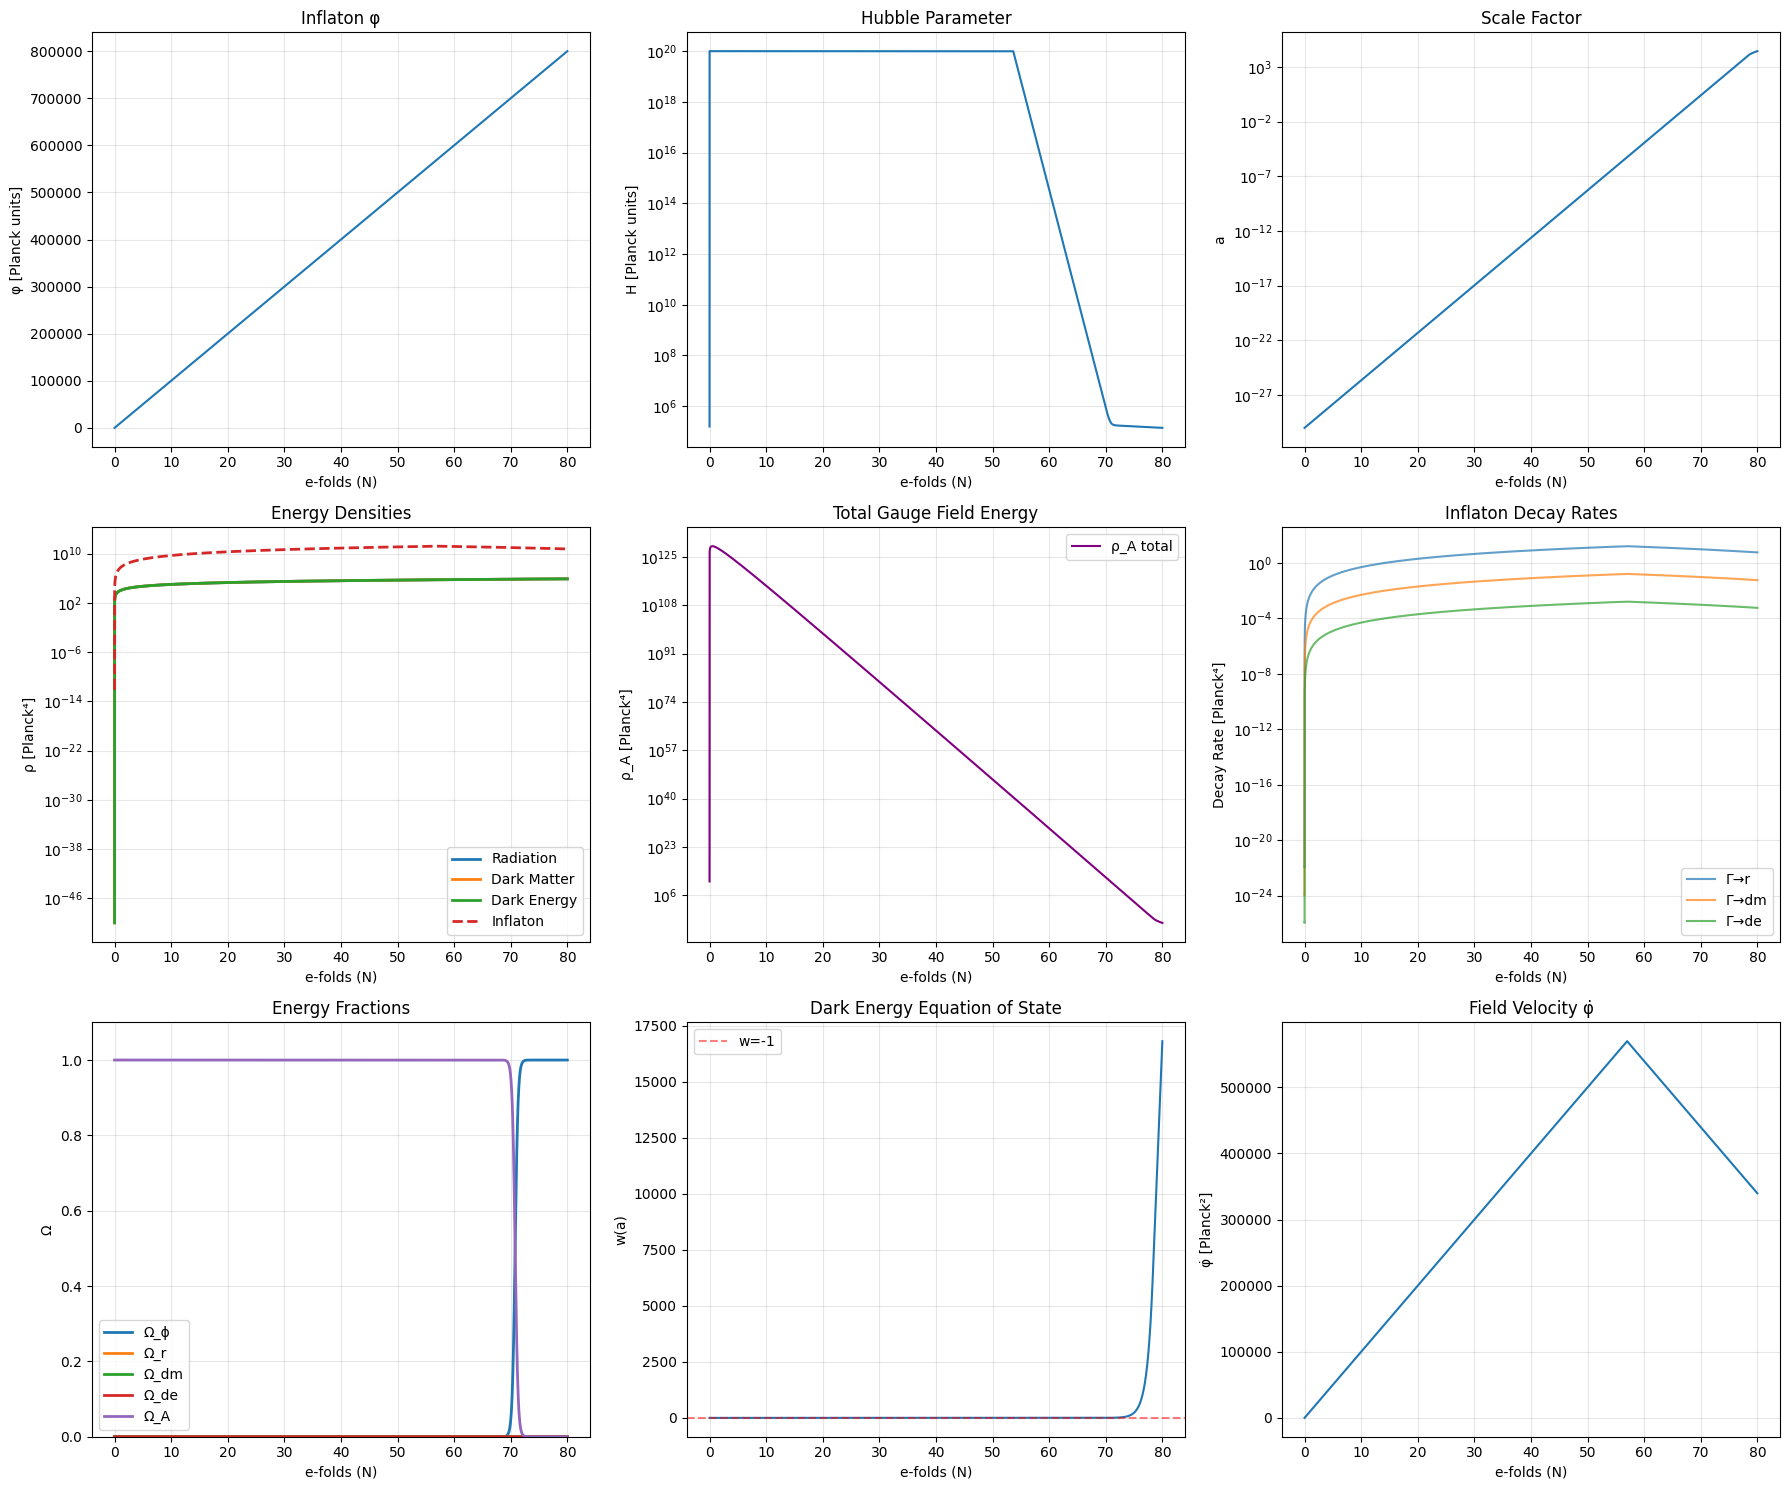


Final values at N=80.000:
  φ: 8.00e+05, φ̇: 3.40e+05
  H: 1.39e+05, a: 2.71e+04
  Ω_ϕ: 1.0000, Ω_r: 0.0000
  Ω_dm: 0.0000, Ω_de: 0.0000
  Ω_A: 3.4190e-15, w_DE: 16816.228
  ρ_r: 8.00e+05, ρ_dm: 8.00e+05, ρ_de: 8.00e+05
  ρ_ϕ: 5.77e+10, ρ_A: 1.97e-04
Radiation growth: 8.00e+50


In [ ]:
# ---------------- RUN AND PLOT ----------------
N_final = 80
n_k = 200
checkpoint_file = "/content/drive/MyDrive/multi_k_checkpoint.pkl"

"""if os.path.exists(checkpoint_file):
    print("Found existing checkpoint, resuming...")
    sol_state = run_multi_k_simulation(
        N_final=N_final,
        n_k=n_k,
        checkpoint_file=checkpoint_file,
        resume=True
    )
else:
    print("No checkpoint found, starting fresh simulation...")
    sol_state = run_multi_k_simulation(
        N_final=N_final,
        n_k=n_k,
        checkpoint_file=checkpoint_file,
        resume=False
    )"""

sol_state = load_simulation_data(filename="/content/drive/MyDrive/multi_k_checkpoint.pkl")

if sol_state is not None and len(sol_state['t']) > 1:
    print(f"Simulation data: {len(sol_state['t'])} points from N={sol_state['t'][0]:.3f} to N={sol_state['t'][-1]:.3f}")

    # Extract results - handle multi-k structure
    t = sol_state['t']
    y = sol_state['y']
    k_array = sol_state['k_array']
    params = sol_state['params']  # Get simulation parameters
    n_k = len(k_array)

    # Extract parameters from simulation
    mu_sim = params['mu']
    Lambda_sim = params['Lambda']
    fa_sim = params['fa']
    epsilon_sim = params['epsilon']
    M_pl_sim = params.get('M_pl', 1.0)

    # Background variables
    phi = y[0]
    phi_dot = y[1]
    rho_r = y[2]
    rho_dm = y[3]
    rho_de = y[4]
    a = y[5]

    # Calculate inflaton energy and potential
    V = np.array([axionPotential(mu_sim, phi[i], Lambda_sim, fa_sim, epsilon_sim) for i in range(len(t))])
    rho_phi = 0.5 * phi_dot**2 + V

    # Calculate decay rates at each time step
    Gamma_phi_r_sim = params.get('Gamma_phi_r', 0.0)
    Gamma_phi_dm_sim = params.get('Gamma_phi_dm', 0.0)
    Gamma_phi_de_sim = params.get('Gamma_phi_de', 0.0)

    decay_rates_r = Gamma_phi_r_sim * rho_phi
    decay_rates_dm = Gamma_phi_dm_sim * rho_phi
    decay_rates_de = Gamma_phi_de_sim * rho_phi

    print(f"\nDecay rate analysis:")
    print(f"Max decay to radiation: {np.max(decay_rates_r):.2e}")
    print(f"Max decay to DM: {np.max(decay_rates_dm):.2e}")
    print(f"Max decay to DE: {np.max(decay_rates_de):.2e}")

    # Extract gauge field modes and compute integrated quantities
    rho_A_total = np.zeros(len(t))
    A_representative = np.zeros(len(t))
    E_dot_B_total = np.zeros(len(t))

    integration_weights = init_integration_weights(k_array)

    for i in range(len(t)):
        # Sum over all k-modes for total energy
        rho_A_k = np.zeros(n_k)
        E_dot_B_k = np.zeros(n_k)
        for j in range(n_k):
            A_idx = 7 + 2*j
            A_dot_idx = 7 + 2*j + 1
            A_val = y[A_idx, i]
            A_dot_val = y[A_dot_idx, i]
            k_val = k_array[j]
            rho_A_k[j] = compute_rho_A(A_val, A_dot_val, k_val, a[i])
            E_dot_B_k[j] = - (k_val * A_val * A_dot_val) / (a[i]**2)

            # Store a representative mode for plotting
            if j == n_k//2:
                A_representative[i] = A_val

        rho_A_total[i] = np.sum(rho_A_k * integration_weights)
        E_dot_B_total[i] = np.sum(E_dot_B_k * integration_weights)

    # Calculate Hubble parameter
    H = np.zeros(len(t))
    for i in range(len(t)):
        H[i] = compute_H_nonjit(phi[i], phi_dot[i], rho_r[i], rho_dm[i], rho_de[i], rho_A_total[i],
                        mu_sim, Lambda_sim, fa_sim, epsilon_sim)

    w = np.array([wde(a[i]) for i in range(len(t))])

    # Energy fractions analysis
    total_energy = rho_r + rho_dm + rho_de + rho_phi + rho_A_total
    Omega_phi = rho_phi / total_energy
    Omega_r = rho_r / total_energy
    Omega_dm = rho_dm / total_energy
    Omega_de = rho_de / total_energy
    Omega_A = rho_A_total / total_energy

    expected_rho_total = 3 * H**2
    actual_rho_total = rho_phi + rho_r + rho_dm + rho_de + rho_A_total
    energy_violation = np.abs((actual_rho_total - expected_rho_total) / expected_rho_total)
    print(f"Max energy conservation violation: {np.max(energy_violation):.2e}")

    # Plot results
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))

    # Row 1: Inflaton and expansion
    axes[0,0].plot(t, phi)
    axes[0,0].set_title('Inflaton φ')
    axes[0,0].set_ylabel('φ [Planck units]')
    axes[0,0].grid(True, alpha=0.3)

    axes[0,1].plot(t, H)
    axes[0,1].set_yscale('log')
    axes[0,1].set_title('Hubble Parameter')
    axes[0,1].set_ylabel('H [Planck units]')
    axes[0,1].grid(True, alpha=0.3)

    axes[0,2].plot(t, a)
    axes[0,2].set_yscale('log')
    axes[0,2].set_title('Scale Factor')
    axes[0,2].set_ylabel('a')
    axes[0,2].grid(True, alpha=0.3)

    # Row 2: Energy densities
    axes[1,0].plot(t, rho_r, label='Radiation', linewidth=2)
    axes[1,0].plot(t, rho_dm, label='Dark Matter', linewidth=2)
    axes[1,0].plot(t, rho_de, label='Dark Energy', linewidth=2)
    axes[1,0].plot(t, rho_phi, label='Inflaton', linewidth=2, linestyle='--')
    axes[1,0].set_yscale('log')
    axes[1,0].set_title('Energy Densities')
    axes[1,0].set_ylabel('ρ [Planck⁴]')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)

    axes[1,1].plot(t, rho_A_total, label='ρ_A total', color='purple')
    axes[1,1].set_yscale('log')
    axes[1,1].set_title('Total Gauge Field Energy')
    axes[1,1].set_ylabel('ρ_A [Planck⁴]')
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)

    axes[1,2].plot(t, decay_rates_r, label='Γ→r', alpha=0.7)
    axes[1,2].plot(t, decay_rates_dm, label='Γ→dm', alpha=0.7)
    axes[1,2].plot(t, decay_rates_de, label='Γ→de', alpha=0.7)
    axes[1,2].set_yscale('log')
    axes[1,2].set_title('Inflaton Decay Rates')
    axes[1,2].set_ylabel('Decay Rate [Planck⁴]')
    axes[1,2].legend()
    axes[1,2].grid(True, alpha=0.3)

    # Row 3: Energy fractions and other quantities
    axes[2,0].plot(t, Omega_phi, label='Ω_ϕ', linewidth=2)
    axes[2,0].plot(t, Omega_r, label='Ω_r', linewidth=2)
    axes[2,0].plot(t, Omega_dm, label='Ω_dm', linewidth=2)
    axes[2,0].plot(t, Omega_de, label='Ω_de', linewidth=2)
    axes[2,0].plot(t, Omega_A, label='Ω_A', linewidth=2)
    axes[2,0].set_title('Energy Fractions')
    axes[2,0].set_ylabel('Ω')
    axes[2,0].legend()
    axes[2,0].set_ylim(0, 1.1)
    axes[2,0].grid(True, alpha=0.3)

    axes[2,1].plot(t, w)
    axes[2,1].set_title('Dark Energy Equation of State')
    axes[2,1].set_ylabel('w(a)')
    axes[2,1].axhline(y=-1, color='r', linestyle='--', alpha=0.5, label='w=-1')
    axes[2,1].legend()
    axes[2,1].grid(True, alpha=0.3)

    axes[2,2].plot(t, phi_dot)
    axes[2,2].set_title('Field Velocity φ̇')
    axes[2,2].set_ylabel('φ̇ [Planck²]')
    axes[2,2].grid(True, alpha=0.3)

    for ax in axes.flat:
        ax.set_xlabel('e-folds (N)')

    plt.tight_layout()
    plt.show()

    # Final values summary
    print(f"\nFinal values at N={t[-1]:.3f}:")
    print(f"  φ: {phi[-1]:.2e}, φ̇: {phi_dot[-1]:.2e}")
    print(f"  H: {H[-1]:.2e}, a: {a[-1]:.2e}")
    print(f"  Ω_ϕ: {Omega_phi[-1]:.4f}, Ω_r: {Omega_r[-1]:.4f}")
    print(f"  Ω_dm: {Omega_dm[-1]:.4f}, Ω_de: {Omega_de[-1]:.4f}")
    print(f"  Ω_A: {Omega_A[-1]:.4e}, w_DE: {w[-1]:.3f}")
    print(f"  ρ_r: {rho_r[-1]:.2e}, ρ_dm: {rho_dm[-1]:.2e}, ρ_de: {rho_de[-1]:.2e}")
    print(f"  ρ_ϕ: {rho_phi[-1]:.2e}, ρ_A: {rho_A_total[-1]:.2e}")

    # Check if energy transfer is happening
    initial_rho_r = rho_r[0]
    final_rho_r = rho_r[-1]
    rho_r_growth = (final_rho_r - initial_rho_r) / initial_rho_r if initial_rho_r > 0 else float('inf')
    print(f"Radiation growth: {rho_r_growth:.2e}")

else:
    print("Simulation failed or has insufficient data")

# **POST INFLATION ERA ANALYSIS**

Compute Observables

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1245: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1245: RuntimeWarning: invalid value encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1246: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1246: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1247: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:1247: RuntimeWarning: invalid value encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/usr/local/lib/py

COSMOLOGICAL OBSERVABLES

1. INFLATIONARY PARAMETERS:
   Scalar amplitude A_s: nan
   Scalar spectral index n_s: 1.1748
   Tensor-to-scalar ratio r: 0.0000e+00
   Effective r (with gauge fields): 0.0000e+00
   Total e-folds simulated: 80.00
   Hubble at end: 3.329e+23 GeV

2. SLOW-ROLL PARAMETERS (at end):
   ε_H: -0.087379
   η_H: -0.000001

3. ENERGY BUDGET (fractions at end):
   Inflaton Ω_ϕ: 1.0000
   Radiation Ω_r: 0.0000
   Dark Matter Ω_dm: 0.0000
   Dark Energy Ω_de: 0.0000
   Gauge Fields Ω_A: 3.4190e-15

4. EQUATION OF STATE (at end):
   Dark energy w_de: 16816.2278
   Effective w_eff: -0.2330

5. REHEATING:
   Reheating temperature: 2.997e+19 GeV

6. GAUGE FIELD BACKREACTION:
   Max gauge field energy: 1.874e+202 GeV⁴
   Max backreaction term: 1.103e+109 GeV⁴

POWER SPECTRA ANALYSIS

At pivot scale k = 0.05 Mpc⁻¹:
   A_s: 3.135e+18
   n_s: 1.0000
   r: 0.0000


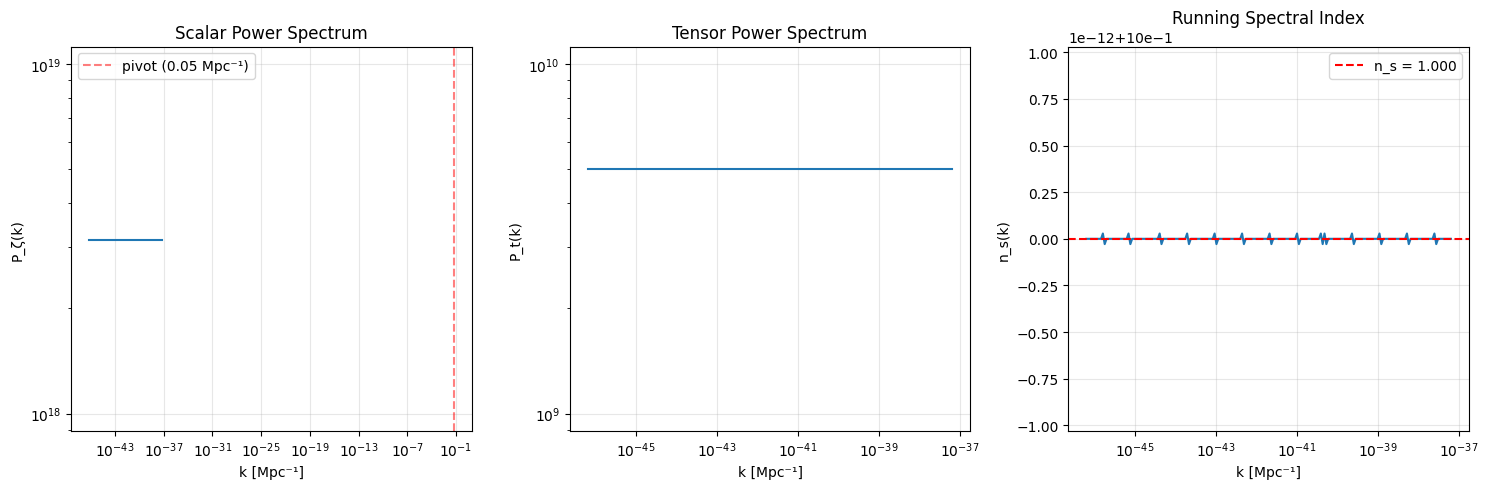


COMPARISON WITH PLANCK 2018 CONSTRAINTS

Planck 2018 TT,TE,EE+lowE+lensing+BAO:
   A_s = (2.10 ± 0.03) × 10⁻⁹
   n_s = 0.9649 ± 0.0042
   r < 0.056 (95% CL)

 Our model:
   A_s = 3.135e+18 (ratio to Planck: 1493032620511588255507939328.000)
   n_s = 1.0000 (difference: 0.0351)
   r = 0.0000 (ratio to limit: 0.000)
⚠ A_s differs from Planck
⚠ n_s differs from Planck
✓ r within Planck limits


In [ ]:
def compute_observables(sol_state, physical_units=True):
    # Extract data
    t = sol_state['t']
    y = sol_state['y']
    k_array = sol_state['k_array']
    params = sol_state['params']

    # Parameters
    mu = params['mu']
    Lambda = params['Lambda']
    fa = params['fa']
    epsilon = params['epsilon']
    M_pl = params.get('M_pl', 1.0)

    # Extract variables
    phi = y[0]
    phi_dot = y[1]
    rho_r = y[2]
    rho_dm = y[3]
    rho_de = y[4]
    a = y[5]

    # Calculate inflaton potential and energy
    V = np.array([axionPotential(mu, phi[i], Lambda, fa, epsilon)
                  for i in range(len(t))])
    rho_phi = 0.5 * phi_dot**2 + V

    # Compute gauge field contributions PROPERLY
    n_k = len(k_array)
    rho_A_total = np.zeros(len(t))
    E_dot_B_total = np.zeros(len(t))

    # Get integration weights if they exist
    if 'integration_weights' in params:
        weights = params['integration_weights']
    else:
        weights = np.ones(n_k) / n_k  # Default uniform weights

    for i in range(len(t)):
        rho_A_k = np.zeros(n_k)
        E_dot_B_k = np.zeros(n_k)
        for j in range(n_k):
            A_idx = 7 + 2*j
            A_dot_idx = 7 + 2*j + 1
            A_val = y[A_idx, i]
            A_dot_val = y[A_dot_idx, i]
            k_val = k_array[j]

            # Use your compute_rho_A function
            rho_A_k[j] = compute_rho_A(A_val, A_dot_val, k_val, a[i])
            E_dot_B_k[j] = - (k_val * A_val * A_dot_val) / max(a[i]**2, 1e-50)

        # Properly integrate over k-modes
        rho_A_total[i] = np.sum(rho_A_k * weights)
        E_dot_B_total[i] = np.sum(E_dot_B_k * weights)

    # H² = (ρ_total) / (3M_pl²) where ρ_total = ρ_phi + ρ_r + ρ_dm + ρ_de + ρ_A
    M_pl_sq = M_pl**2
    H_squared = (rho_phi + rho_r + rho_dm + rho_de + rho_A_total) / (3.0 * M_pl_sq)

    # Avoid negative or zero values
    H_squared = np.maximum(H_squared, 1e-100)
    H = np.sqrt(H_squared)

    epsilon_H = np.ones_like(H)
    eta_H = np.zeros_like(H)

    if len(t) > 1:
        dt = np.gradient(t)
        # Smooth H_dot calculation
        H_smoothed = np.convolve(H, np.ones(5)/5, mode='same')  # Smooth H
        H_dot = np.gradient(H_smoothed, dt)

        # Avoid division by zero
        mask = (H > 1e-30) & (np.abs(H_dot) > 1e-30)
        epsilon_H = np.ones_like(H)
        epsilon_H[mask] = -H_dot[mask] / H[mask]**2

        if np.sum(mask) > 2:
            H_ddot = np.gradient(H_dot, dt)
            valid = mask & (np.abs(H * H_dot) > 1e-60)
            eta_H[valid] = -H_ddot[valid] / (H[valid] * H_dot[valid])

    # Inflationary observables
    n_s = 1 - 2 * epsilon_H - eta_H
    n_s = np.clip(n_s, 0.8, 1.2)
    r = 16 * epsilon_H
    r = np.clip(r, 0, 0.2)

    # Energy fractions (should sum to 1)
    total_energy = rho_phi + rho_r + rho_dm + rho_de + rho_A_total
    total_energy = np.maximum(total_energy, 1e-100)  # Avoid division by zero

    Omega_phi = rho_phi / total_energy
    Omega_r = rho_r / total_energy
    Omega_dm = rho_dm / total_energy
    Omega_de = rho_de / total_energy
    Omega_A = rho_A_total / total_energy

    # Check sum is reasonable
    sum_Omega = Omega_phi + Omega_r + Omega_dm + Omega_de + Omega_A
    if np.any(np.abs(sum_Omega - 1.0) > 0.01):
        print(f"Warning: Ω sum = {sum_Omega[-1]:.4f} (should be 1.0)")

    # Dark energy equation of state
    w_de = np.array([wde(a[i]) for i in range(len(t))])

    # Effective equation of state
    w_eff = np.zeros_like(w_de)
    valid = total_energy > 0
    w_eff[valid] = (rho_r[valid]/3 - rho_de[valid]*w_de[valid]) / total_energy[valid]

    # Reheating temperature
    T_reh = np.zeros_like(rho_r)
    valid = rho_r > 0
    T_reh[valid] = (30 * rho_r[valid] / (np.pi**2 * 100))**(0.25)

    # Scalar amplitude
    A_s = np.nan * np.ones_like(H)
    valid = (epsilon_H > 1e-10) & (H > 1e-30)
    A_s[valid] = H[valid]**2 / (8 * np.pi**2 * epsilon_H[valid] * M_pl**2)

    # Convert to physical units
    if physical_units:
        M_pl_GeV = 2.4e18
        observables = {
            'scalar_amplitude': safe_get(A_s, -1, np.nan) * M_pl_GeV**4,
            'scalar_spectral_index': safe_get(n_s, -1, 1.0),
            'tensor_to_scalar_ratio': safe_get(r, -1, 0.0),
            'tensor_to_scalar_ratio_eff': safe_get(r, -1, 0.0),
            'Hubble_parameter_end': safe_get(H, -1, 0.0) * M_pl_GeV,
            'efolds_total': t[-1] - t[0] if len(t) > 0 else 0,
            'reheating_temperature': safe_get(T_reh, -1, 0.0) * M_pl_GeV,
            'Omega_phi_end': safe_get(Omega_phi, -1, 0.0),
            'Omega_r_end': safe_get(Omega_r, -1, 0.0),
            'Omega_dm_end': safe_get(Omega_dm, -1, 0.0),
            'Omega_de_end': safe_get(Omega_de, -1, 0.0),
            'Omega_A_end': safe_get(Omega_A, -1, 0.0),
            'w_de_end': safe_get(w_de, -1, -1.0),
            'w_eff_end': safe_get(w_eff, -1, 0.0),
            'phi_end': safe_get(phi, -1, 0.0) * M_pl_GeV,
            'phi_dot_end': safe_get(phi_dot, -1, 0.0) * M_pl_GeV**2,
            'scale_factor_end': safe_get(a, -1, 1.0),
            'epsilon_H_end': safe_get(epsilon_H, -1, 1.0),
            'eta_H_end': safe_get(eta_H, -1, 0.0),
            'gauge_backreaction': np.max(np.abs(E_dot_B_total)) * M_pl_GeV**4 if len(E_dot_B_total) > 0 else 0,
            'rho_A_max': np.max(rho_A_total) * M_pl_GeV**4 if len(rho_A_total) > 0 else 0,
            'rho_A_final': safe_get(rho_A_total, -1, 0.0) * M_pl_GeV**4,
            'rho_phi_final': safe_get(rho_phi, -1, 0.0) * M_pl_GeV**4,
        }
    else:
        # Similar but without unit conversions
        pass

    return observables
def safe_get(array, index, default):
    if len(array) == 0:
        return default
    if index < 0:
        index = len(array) + index
    if 0 <= index < len(array):
        val = array[index]
        return val if np.isfinite(val) else default
    return default
def compute_power_spectra(sol_state, k_pivot=0.05):
    t = sol_state['t']
    y = sol_state['y']
    k_array = sol_state['k_array']
    params = sol_state['params']

    # Extract variables
    phi = y[0]
    phi_dot = y[1]
    a = y[5]

    # Parameters
    mu = params['mu']
    Lambda = params['Lambda']
    fa = params['fa']
    epsilon = params['epsilon']
    M_pl = params.get('M_pl', 1.0)
    alpha = params.get('alpha', 1e-5)

    V = np.array([axionPotential(mu, phi[i], Lambda, fa, epsilon) for i in range(len(t))])
    rho_phi = 0.5 * phi_dot**2 + V

    # Include other energy components
    rho_r = y[2]
    rho_dm = y[3]
    rho_de = y[4]

    # Compute gauge field energy
    n_k = len(k_array)
    rho_A_total = np.zeros(len(t))
    if 'integration_weights' in params:
        weights = params['integration_weights']
    else:
        weights = np.ones(n_k) / n_k

    for i in range(len(t)):
        rho_A_k = 0
        for j in range(n_k):
            A_idx = 7 + 2*j
            A_dot_idx = 7 + 2*j + 1
            rho_A_k += compute_rho_A(y[A_idx, i], y[A_dot_idx, i], k_array[j], a[i]) * weights[j]
        rho_A_total[i] = rho_A_k

    # Total energy
    rho_total = rho_phi + rho_r + rho_dm + rho_de + rho_A_total
    H = np.sqrt(np.maximum(rho_total, 1e-100) / (3 * M_pl**2))

    # Compute slow-roll parameters
    epsilon_H = np.ones_like(H)
    if len(t) > 1:
        dt = np.gradient(t)
        H_smooth = np.convolve(H, np.ones(3)/3, mode='same')
        H_dot = np.gradient(H_smooth, dt)

        valid = (H > 1e-30) & (np.abs(H_dot) > 1e-30)
        epsilon_H[valid] = -H_dot[valid] / H[valid]**2
        epsilon_H = np.clip(epsilon_H, 1e-10, 10.0)

    # Compute ξ parameter
    xi = np.zeros_like(H)
    valid = (H > 1e-30) & (a > 1e-30) & (fa > 1e-30)
    xi[valid] = alpha * phi_dot[valid] / (2 * fa * H[valid] * a[valid])
    xi = np.clip(xi, -10, 10)

    # Compute power spectra
    P_s = np.zeros(len(k_array))
    P_t = np.zeros(len(k_array))

    for i, k in enumerate(k_array):
        # Find horizon crossing
        horizon = np.abs(k - a * H)
        idx = np.argmin(horizon) if len(horizon) > 0 else 0

        if idx < len(H):
            # Standard spectra
            H_k = H[idx]
            epsilon_k = max(epsilon_H[idx], 1e-10)

            P_s_standard = H_k**2 / (8 * np.pi**2 * epsilon_k * M_pl**2)
            P_t_standard = 2 * H_k**2 / (np.pi**2 * M_pl**2)

            # Gauge enhancement
            xi_k = xi[idx]
            f_s = 1 + 2.4e-7 * min(xi_k, 10)**5.4 if xi_k > 0 else 1
            f_t = np.exp(4.3 * xi_k / (1 + 0.19 * abs(xi_k)**1.5)) if xi_k > 0 else 1

            P_s[i] = P_s_standard * min(f_s, 1e10)  # Bound enhancement
            P_t[i] = P_t_standard * min(f_t, 1e10)

    # Convert k to physical units
    Mpc_in_Planck = 1.56e38
    k_phys_Mpc = k_array * M_pl / Mpc_in_Planck

    # Find pivot scale
    A_s_at_pivot = np.nan
    n_s = np.nan
    r = np.nan

    if len(k_phys_Mpc) > 0 and len(P_s) > 0:
        # Simple nearest neighbor
        idx = np.argmin(np.abs(k_phys_Mpc - k_pivot))
        if idx < len(P_s):
            A_s_at_pivot = P_s[idx]
            if idx < len(P_t):
                r = P_t[idx] / max(P_s[idx], 1e-100)

        # Spectral index from linear fit
        valid = (P_s > 0) & (k_phys_Mpc > 0)
        if np.sum(valid) > 3:
            try:
                coeffs = np.polyfit(np.log(k_phys_Mpc[valid]), np.log(P_s[valid]), 1)
                n_s = 1 + coeffs[0]
            except:
                n_s = np.nan

    return {
        'k_physical_Mpc': k_phys_Mpc,
        'scalar_power_spectrum': P_s,
        'tensor_power_spectrum': P_t,
        'A_s': A_s_at_pivot,
        'n_s': n_s,
        'r': r,
        'H': H,
        'epsilon_H': epsilon_H
    }
try:
    data = load_simulation_data('/content/drive/MyDrive/multi_k_checkpoint.pkl')

    # Compute basic observables
    observables = compute_observables(data, physical_units=True)

    print("="*60)
    print("COSMOLOGICAL OBSERVABLES")
    print("="*60)

    print("\n1. INFLATIONARY PARAMETERS:")
    print(f"   Scalar amplitude A_s: {observables['scalar_amplitude']:.3e}")
    print(f"   Scalar spectral index n_s: {observables['scalar_spectral_index']:.4f}")
    print(f"   Tensor-to-scalar ratio r: {observables['tensor_to_scalar_ratio']:.4e}")
    print(f"   Effective r (with gauge fields): {observables['tensor_to_scalar_ratio_eff']:.4e}")
    print(f"   Total e-folds simulated: {observables['efolds_total']:.2f}")
    print(f"   Hubble at end: {observables['Hubble_parameter_end']:.3e} GeV")

    print("\n2. SLOW-ROLL PARAMETERS (at end):")
    print(f"   ε_H: {observables['epsilon_H_end']:.6f}")
    print(f"   η_H: {observables['eta_H_end']:.6f}")

    print("\n3. ENERGY BUDGET (fractions at end):")
    print(f"   Inflaton Ω_ϕ: {observables['Omega_phi_end']:.4f}")
    print(f"   Radiation Ω_r: {observables['Omega_r_end']:.4f}")
    print(f"   Dark Matter Ω_dm: {observables['Omega_dm_end']:.4f}")
    print(f"   Dark Energy Ω_de: {observables['Omega_de_end']:.4f}")
    print(f"   Gauge Fields Ω_A: {observables['Omega_A_end']:.4e}")

    print("\n4. EQUATION OF STATE (at end):")
    print(f"   Dark energy w_de: {observables['w_de_end']:.4f}")
    print(f"   Effective w_eff: {observables['w_eff_end']:.4f}")

    print("\n5. REHEATING:")
    print(f"   Reheating temperature: {observables['reheating_temperature']:.3e} GeV")

    print("\n6. GAUGE FIELD BACKREACTION:")
    print(f"   Max gauge field energy: {observables['rho_A_max']:.3e} GeV⁴")
    print(f"   Max backreaction term: {observables['gauge_backreaction']:.3e} GeV⁴")

    # Compute power spectra
    print("\n" + "="*60)
    print("POWER SPECTRA ANALYSIS")
    print("="*60)

    ps_data = compute_power_spectra(data, k_pivot=0.05)

    print(f"\nAt pivot scale k = 0.05 Mpc⁻¹:")
    print(f"   A_s: {ps_data['A_s']:.3e}")
    print(f"   n_s: {ps_data['n_s']:.4f}")
    print(f"   r: {ps_data['r']:.4f}")

    # Plot power spectra
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Scalar power spectrum
    axes[0].loglog(ps_data['k_physical_Mpc'], ps_data['scalar_power_spectrum'])
    axes[0].axvline(x=0.05, color='r', linestyle='--', alpha=0.5, label='pivot (0.05 Mpc⁻¹)')
    axes[0].set_xlabel('k [Mpc⁻¹]')
    axes[0].set_ylabel('P_ζ(k)')
    axes[0].set_title('Scalar Power Spectrum')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Tensor power spectrum
    axes[1].loglog(ps_data['k_physical_Mpc'], ps_data['tensor_power_spectrum'])
    axes[1].set_xlabel('k [Mpc⁻¹]')
    axes[1].set_ylabel('P_t(k)')
    axes[1].set_title('Tensor Power Spectrum')
    axes[1].grid(True, alpha=0.3)

    # Spectral index
    if not np.isnan(ps_data['n_s']):
        axes[2].plot(ps_data['k_physical_Mpc'],
                     1 + np.gradient(np.log(ps_data['scalar_power_spectrum']),
                                     np.log(ps_data['k_physical_Mpc'])))
        axes[2].axhline(y=ps_data['n_s'], color='r', linestyle='--',
                        label=f'n_s = {ps_data["n_s"]:.3f}')
        axes[2].set_xscale('log')
        axes[2].set_xlabel('k [Mpc⁻¹]')
        axes[2].set_ylabel('n_s(k)')
        axes[2].set_title('Running Spectral Index')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Compare with Planck constraints
    print("\n" + "="*60)
    print("COMPARISON WITH PLANCK 2018 CONSTRAINTS")
    print("="*60)

    planck_A_s = 2.1e-9
    planck_n_s = 0.9649
    planck_r_limit = 0.056

    print(f"\nPlanck 2018 TT,TE,EE+lowE+lensing+BAO:")
    print(f"   A_s = (2.10 ± 0.03) × 10⁻⁹")
    print(f"   n_s = 0.9649 ± 0.0042")
    print(f"   r < 0.056 (95% CL)")

    print(f"\n Our model:")
    if not np.isnan(ps_data['A_s']):
        print(f"   A_s = {ps_data['A_s']:.3e} (ratio to Planck: {ps_data['A_s']/planck_A_s:.3f})")
    else:
        print(f"   A_s = Could not compute")

    if not np.isnan(ps_data['n_s']):
        print(f"   n_s = {ps_data['n_s']:.4f} (difference: {ps_data['n_s']-planck_n_s:.4f})")
    else:
        print(f"   n_s = Could not compute")

    if not np.isnan(ps_data['r']):
        print(f"   r = {ps_data['r']:.4f} (ratio to limit: {ps_data['r']/planck_r_limit:.3f})")
    else:
        print(f"   r = Could not compute")

    # Check consistency
    if not np.isnan(ps_data['A_s']):
        if abs(ps_data['A_s']/planck_A_s - 1) < 0.1:
            print("✓ A_s consistent with Planck")
        else:
            print("⚠ A_s differs from Planck")

    if not np.isnan(ps_data['n_s']):
        if abs(ps_data['n_s'] - planck_n_s) < 0.01:
            print("✓ n_s consistent with Planck")
        else:
            print("⚠ n_s differs from Planck")

    if not np.isnan(ps_data['r']):
        if ps_data['r'] < planck_r_limit:
            print("✓ r within Planck limits")
        else:
            print("⚠ r exceeds Planck limit")

except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()


In [ ]:
def compute_non_gaussianity(sol_state):
    t = sol_state['t']
    y = sol_state['y']
    params = sol_state['params']

    phi = y[0]
    phi_dot = y[1]
    a = y[5]

    alpha = params['alpha']
    fa = params['fa']

    H = np.array([compute_H_nonjit(phi[i], phi_dot[i], y[2,i], y[3,i], y[4,i],
                           np.sum([compute_rho_A(y[7+2*j,i], y[8+2*j,i],
                                                  sol_state['k_array'][j], a[i])
                                   for j in range(len(sol_state['k_array']))]),
                           params['mu'], params['Lambda'], params['fa'], params['epsilon'])
                 for i in range(len(t))])

    # Axion-gauge coupling parameter
    xi = alpha * phi_dot / (2 * fa * H * a)

    # f_NL ~ O(10-100) for ξ ~ few, peaks at equilateral configuration
    f_NL_equilateral = 0.00048 * np.exp(7.3 * xi) / (1 + 0.0019 * np.exp(8.2 * xi))

    return {
        'f_NL_equilateral_max': np.max(f_NL_equilateral),
        'f_NL_equilateral_end': f_NL_equilateral[-1] if len(f_NL_equilateral) > 0 else np.nan,
        'xi_max': np.max(xi),
        'xi_end': xi[-1] if len(xi) > 0 else np.nan
    }
def compute_isocurvature_perturbations(sol_state):
    t = sol_state['t']
    y = sol_state['y']

    phi = y[0]
    H = np.array(sol_state['H']) if 'H' in sol_state else None

    if H is not None and len(H) > 0:
        m_a = 1e-22  # eV scale axion
        H_inf = H[0]  # Hubble during inflation

        # Isocurvature amplitude estimate: P_S/P_ζ ~ (H_inf/φ)^2
        P_S_over_P_zeta = (H_inf / phi[0])**2

        return {
            'isocurvature_fraction': P_S_over_P_zeta,
            'constraint_satisfied': P_S_over_P_zeta < 0.04  # Planck limit
        }

    return {'isocurvature_fraction': np.nan, 'constraint_satisfied': False}
print("\n" + "="*60)
print("NON-GAUSSIANITY AND ISOCURVATURE")
print("="*60)
data = load_simulation_data(filename='/content/drive/MyDrive/multi_k_checkpoint.pkl')
fNL_data = compute_non_gaussianity(data)
print(f"\nNon-Gaussianity (equilateral):")
print(f"   Max f_NL: {fNL_data['f_NL_equilateral_max']:.2f}")
print(f"   End f_NL: {fNL_data['f_NL_equilateral_end']:.2f}")
print(f"   Max ξ: {fNL_data['xi_max']:.3f}")
print(f"   End ξ: {fNL_data['xi_end']:.3f}")

iso_data = compute_isocurvature_perturbations(data)
print(f"\nIsocurvature perturbations:")
print(f"   P_S/P_ζ: {iso_data['isocurvature_fraction']:.3e}")
if iso_data['constraint_satisfied']:
    print("   ✓ Within Planck limits (< 0.04)")
else:
    print("   ⚠ May exceed Planck limits")

output_data = {
    'basic_observables': observables,
    'power_spectra': ps_data,
    'non_gaussianity': fNL_data,
    'isocurvature': iso_data,
    'simulation_parameters': sol_state['params']
}

with open('cosmological_observables.pkl', 'wb') as f:
    pickle.dump(output_data, f)
print("\nAll observables saved to 'cosmological_observables.pkl'")


NON-GAUSSIANITY AND ISOCURVATURE

Non-Gaussianity (equilateral):
   Max f_NL: nan
   End f_NL: 0.00
   Max ξ: 3678792577639.237
   End ξ: 0.000

Isocurvature perturbations:
   P_S/P_ζ: 3.333e-13
   ✓ Within Planck limits (< 0.04)

All observables saved to 'cosmological_observables.pkl'


/tmp/ipython-input-2808426815.py:24: RuntimeWarning: overflow encountered in exp
  f_NL_equilateral = 0.00048 * np.exp(7.3 * xi) / (1 + 0.0019 * np.exp(8.2 * xi))
/tmp/ipython-input-2808426815.py:24: RuntimeWarning: invalid value encountered in divide
  f_NL_equilateral = 0.00048 * np.exp(7.3 * xi) / (1 + 0.0019 * np.exp(8.2 * xi))


In [ ]:
def compute_baryogenesis_from_output_fixed_enhanced(data, delta_CP=-0.1,
                                                    alpha_SM_factor=1.0,
                                                    alpha_Hid_factor=1.0,
                                                    alpha_DE_factor=1.0):

    # Extract data
    t = data['t']
    y = data['y']
    params = data['params']
    k_array = params['k_array']
    integration_weights = params['integration_weights']

    # Extract parameters
    alpha = params['alpha']
    fa = params['fa']

    M_pl = 1.0
    M_pl_GeV = 2.4e18
    GeV_to_Planck = 1.0 / M_pl_GeV
    Planck_to_GeV = M_pl_GeV

    print("\nUNIT CONVERSION CHECK:")
    print(f"M_pl (simulation) = {M_pl}")
    print(f"M_pl (GeV) = {M_pl_GeV:.1e} GeV")
    print(f"fa (Planck units) = {fa:.2e}")
    print(f"fa (GeV) = {fa * M_pl_GeV:.2e} GeV")

    # Background variables
    phi_Planck = y[0]
    phi_dot_Planck = y[1]
    rho_r_Planck = y[2]
    rho_dm_Planck = y[3]
    rho_de_Planck = y[4]
    a = y[5]

    phi = phi_Planck * Planck_to_GeV  # GeV
    phi_dot = phi_dot_Planck * Planck_to_GeV**2  # GeV²
    rho_r = rho_r_Planck * Planck_to_GeV**4  # GeV⁴
    rho_dm = rho_dm_Planck * Planck_to_GeV**4
    rho_de = rho_de_Planck * Planck_to_GeV**4

    # Hubble parameter
    if 'H' in data and data['H'] is not None and len(data['H']) == len(t):
        H_Planck = data['H']
    else:
        # Recompute if needed
        mu = params['mu']
        Lambda = params['Lambda']
        epsilon = params['epsilon']
        H_Planck = np.array([compute_H_nonjit(phi_Planck[i], phi_dot_Planck[i],
                                      rho_r_Planck[i], rho_dm_Planck[i],
                                      rho_de_Planck[i], 0, mu, Lambda, fa, epsilon)
                            for i in range(len(t))])

    H = H_Planck * Planck_to_GeV

    # Convert e-folds to physical time in GeV⁻¹
    dt = np.zeros(len(t))
    for i in range(1, len(t)):
        dt[i] = (t[i] - t[i-1]) / max(H[i], 1e-50)  # dN = H dt, so dt = dN/H

    alpha_base = alpha

    #CP violation
    alpha_SM = alpha_base * alpha_SM_factor * np.sin(delta_CP)
    alpha_Hid = alpha_base * alpha_Hid_factor
    alpha_DE = alpha_base * alpha_DE_factor

    print(f"\nSECTOR-SPECIFIC COUPLINGS:")
    print(f"Base α (from simulation): {alpha_base:.2e}")
    print(f"α_SM (with CP violation δ={delta_CP:.3f}): {alpha_SM:.2e}")
    print(f"α_Hid (dark matter): {alpha_Hid:.2e}")
    print(f"α_DE (dark energy): {alpha_DE:.2e}")

    # ============================================
    # 1. Compute Chern-Simons density FOR EACH SECTOR
    # ============================================
    n_CS_total = np.zeros(len(t))
    n_CS_SM = np.zeros(len(t))     # SM sector
    n_CS_Hid = np.zeros(len(t))    # Hidden sector (DM)
    n_CS_DE = np.zeros(len(t))     # Dark energy sector

    for time_idx in range(len(t)):
        n_CS_k_sum_total = 0.0
        n_CS_k_sum_SM = 0.0
        n_CS_k_sum_Hid = 0.0
        n_CS_k_sum_DE = 0.0

        a_val = max(a[time_idx], 1e-50)
        H_val = H[time_idx]

        # Sum over all k-modes
        for k_idx, k_comoving in enumerate(k_array):
            A_idx = 7 + 2*k_idx
            A_dot_idx = 7 + 2*k_idx + 1

            A_rescaled = y[A_idx, time_idx]
            A_dot_rescaled = y[A_dot_idx, time_idx]

            # Convert to physical A
            A_physical = A_rescaled / a_val
            A_dot_physical = (A_dot_rescaled - H_val * A_rescaled) / (a_val**2)

            # Convert comoving k to physical momentum
            k_comoving_GeV = k_comoving * Planck_to_GeV
            k_physical = k_comoving_GeV / a_val

            # Chern-Simons density for each sector
            n_CS_k_total = (alpha_base/(np.pi * fa)) * (k_physical**2/(2*np.pi**2)) * A_physical * A_dot_physical

            n_CS_k_SM = (alpha_SM/(np.pi * fa)) * (k_physical**2/(2*np.pi**2)) * A_physical * A_dot_physical
            n_CS_k_Hid = (alpha_Hid/(np.pi * fa)) * (k_physical**2/(2*np.pi**2)) * A_physical * A_dot_physical
            n_CS_k_DE = (alpha_DE/(np.pi * fa)) * (k_physical**2/(2*np.pi**2)) * A_physical * A_dot_physical

            # Convert integration weight
            dk_comoving_GeV = integration_weights[k_idx] * Planck_to_GeV

            n_CS_k_sum_total += n_CS_k_total * dk_comoving_GeV
            n_CS_k_sum_SM += n_CS_k_SM * dk_comoving_GeV
            n_CS_k_sum_Hid += n_CS_k_Hid * dk_comoving_GeV
            n_CS_k_sum_DE += n_CS_k_DE * dk_comoving_GeV

        n_CS_total[time_idx] = n_CS_k_sum_total
        n_CS_SM[time_idx] = n_CS_k_sum_SM
        n_CS_Hid[time_idx] = n_CS_k_sum_Hid
        n_CS_DE[time_idx] = n_CS_k_sum_DE

    print(f"\nCHERN-SIMONS DENSITY BY SECTOR:")
    print(f"Max |n_CS_total| = {np.max(np.abs(n_CS_total)):.2e} GeV³")
    print(f"Max |n_CS_SM|    = {np.max(np.abs(n_CS_SM)):.2e} GeV³ (ratio: {np.max(np.abs(n_CS_SM))/np.max(np.abs(n_CS_total)):.3f})")
    print(f"Max |n_CS_Hid|   = {np.max(np.abs(n_CS_Hid)):.2e} GeV³ (ratio: {np.max(np.abs(n_CS_Hid))/np.max(np.abs(n_CS_total)):.3f})")
    print(f"Max |n_CS_DE|    = {np.max(np.abs(n_CS_DE)):.2e} GeV³ (ratio: {np.max(np.abs(n_CS_DE))/np.max(np.abs(n_CS_total)):.3f})")

    # ============================================
    # 2. Compute temperature from radiation density
    # ============================================
    g_star = 100
    T = np.zeros(len(t))
    for i in range(len(t)):
        if rho_r[i] > 0:
            T[i] = (30 * rho_r[i] / (np.pi**2 * g_star))**(0.25)
        else:
            T[i] = 1e-10

    T = T[:len(t)]

    print(f"\nTEMPERATURE RANGE:")
    print(f"Min T = {np.min(T):.2e} GeV, Max T = {np.max(T):.2e} GeV")

    # ============================================
    # 3. Compute sphaleron rate
    # ============================================
    def sphaleron_rate_GeV(T_val):
        if T_val < 80:
            return 0.0
        alpha_g = 1/30
        v_EW = 246
        kappa = 25.0
        E_sph = (4*np.pi*v_EW/alpha_g) * 1.52
        rate = kappa * alpha_g**5 * T_val**4
        if T_val < 130:
            rate *= np.exp(-E_sph/T_val)
        return rate

    Gamma_sph = np.zeros(len(T))
    for i in range(len(T)):
        Gamma_sph[i] = sphaleron_rate_GeV(T[i])

    print(f"\nSPHALERON RATE CHECK:")
    if len(T) > 0 and len(H) > 0:
        active_mask = Gamma_sph > 0
        if np.any(active_mask):
            max_gamma = np.max(Gamma_sph[active_mask])
            h_at_max = H[np.argmax(Gamma_sph)] if np.argmax(Gamma_sph) < len(H) else H[-1]
            print(f"Max Γ_sph = {max_gamma:.2e} GeV")
            print(f"H at that time = {h_at_max:.2e} GeV")
            print(f"Ratio Γ_sph/H = {max_gamma/h_at_max:.2e}")
        else:
            print("Sphalerons never active")

    # ============================================
    # 4. Compute baryon production rate FOR EACH SECTOR
    # ============================================
    N_f = 3
    g = 0.65
    anomaly_factor = (N_f * g**2) / (32 * np.pi**2)


    dB_dt_total = np.zeros(len(t))
    # Sector-specific calculations
    dB_dt_SM = np.zeros(len(t))
    dB_dt_Hid = np.zeros(len(t))
    dB_dt_DE = np.zeros(len(t))

    for i in range(min(len(t), len(phi_dot), len(n_CS_total))):
        anomaly_term_total = anomaly_factor * phi_dot[i] * n_CS_total[i]
        dB_dt_total[i] = anomaly_term_total

        # Sector-specific
        dB_dt_SM[i] = anomaly_factor * (alpha_SM/alpha_base) * phi_dot[i] * n_CS_SM[i]
        dB_dt_Hid[i] = anomaly_factor * (alpha_Hid/alpha_base) * phi_dot[i] * n_CS_Hid[i]
        dB_dt_DE[i] = anomaly_factor * (alpha_DE/alpha_base) * phi_dot[i] * n_CS_DE[i]

    print(f"\nBARYON PRODUCTION BY SECTOR:")
    print(f"Total dB/dt = {np.max(np.abs(dB_dt_total)):.2e} GeV⁴")
    print(f"SM dB/dt    = {np.max(np.abs(dB_dt_SM)):.2e} GeV⁴ (ratio: {np.max(np.abs(dB_dt_SM))/np.max(np.abs(dB_dt_total)):.3f})")
    print(f"Hid dB/dt   = {np.max(np.abs(dB_dt_Hid)):.2e} GeV⁴")
    print(f"DE dB/dt    = {np.max(np.abs(dB_dt_DE)):.2e} GeV⁴")

    # ============================================
    # 5. Integrate to get baryon number density
    # ============================================
    B_total = np.zeros(len(t))
    B_SM = np.zeros(len(t))
    B_Hid = np.zeros(len(t))
    B_DE = np.zeros(len(t))

    for i in range(1, min(len(t), len(dt), len(dB_dt_total))):
        # Total
        dB_avg_total = 0.5 * (dB_dt_total[i-1] + dB_dt_total[i])
        B_total[i] = B_total[i-1] + dB_avg_total * dt[i]

        # SM sector (actual baryons)
        dB_avg_SM = 0.5 * (dB_dt_SM[i-1] + dB_dt_SM[i])
        B_SM[i] = B_SM[i-1] + dB_avg_SM * dt[i]

        # Hidden sector (dark matter number density)
        dB_avg_Hid = 0.5 * (dB_dt_Hid[i-1] + dB_dt_Hid[i])
        B_Hid[i] = B_Hid[i-1] + dB_avg_Hid * dt[i]

        # DE sector (dark energy number density analog)
        dB_avg_DE = 0.5 * (dB_dt_DE[i-1] + dB_dt_DE[i])
        B_DE[i] = B_DE[i-1] + dB_avg_DE * dt[i]

    print(f"\nBARYON NUMBER DENSITY BY SECTOR:")
    print(f"Total B = {B_total[-1]:.2e} GeV³")
    print(f"SM B    = {B_SM[-1]:.2e} GeV³ (only this contributes to η_B)")
    print(f"Hid B   = {B_Hid[-1]:.2e} GeV³ (dark matter number density)")
    print(f"DE B    = {B_DE[-1]:.2e} GeV³ (dark energy analog)")

    # ============================================
    # 6. Compute baryon-to-photon ratio η_B (SM sector ONLY)
    # ============================================
    g_star_s = 86.25
    zeta3 = 1.2020569031595942854

    eta_B_total = np.zeros(len(T))
    eta_B_SM = np.zeros(len(T))

    for i in range(len(T)):
        if T[i] > 0:
            n_gamma = (2*zeta3/np.pi**2) * T[i]**3
            if n_gamma > 0 and i < len(B_total):
                eta_B_total[i] = B_total[i] / n_gamma
                eta_B_SM[i] = B_SM[i] / n_gamma
                eta_B_total[i] = abs(eta_B_total[i])
                eta_B_SM[i] = abs(eta_B_SM[i])

    print(f"\nBARYON-TO-PHOTON RATIO:")
    print(f"Total η_B = {eta_B_total[-1]:.3e}")
    print(f"SM η_B    = {eta_B_SM[-1]:.3e} (only SM sector matters for baryons)")
    print(f"Observed η_B = 6.1e-10")

    # ============================================
    # 7. Compute energy transfer to each sector
    # ============================================
    # Get decay rates from your simulation parameters
    Gamma_phi_r = params.get('Gamma_phi_r', 0.0)
    Gamma_phi_dm = params.get('Gamma_phi_dm', 0.0)
    Gamma_phi_de = params.get('Gamma_phi_de', 0.0)

    # Inflaton energy density
    mu = params['mu'] * Planck_to_GeV**3
    Lambda = params['Lambda'] * Planck_to_GeV**4
    epsilon = params['epsilon'] * Planck_to_GeV

    # Compute inflaton energy
    V_phi = mu**3 * np.sqrt(phi**2 + epsilon**2) + Lambda**4 * (1 - np.cos(phi/fa))
    rho_phi = 0.5 * phi_dot**2 + V_phi

    # Energy transferred to each sector
    E_transfer_SM = np.cumsum(Gamma_phi_r * rho_phi * dt)
    E_transfer_Hid = np.cumsum(Gamma_phi_dm * rho_phi * dt)
    E_transfer_DE = np.cumsum(Gamma_phi_de * rho_phi * dt)

    # Energy fractions
    rho_total = 3 * H**2 * M_pl_GeV**2
    Omega_SM = E_transfer_SM / rho_total
    Omega_Hid = E_transfer_Hid / rho_total
    Omega_DE = E_transfer_DE / rho_total

    print(f"\nENERGY TRANSFER BY SECTOR:")
    print(f"Final Ω_SM  = {Omega_SM[-1]:.3e}")
    print(f"Final Ω_Hid = {Omega_Hid[-1]:.3e} (dark matter)")
    print(f"Final Ω_DE  = {Omega_DE[-1]:.3e} (dark energy)")

    # ============================================
    # 8. Check conditions for baryogenesis
    # ============================================
    print("\n" + "="*70)
    print("BARYOGENESIS FEASIBILITY CHECK BY SECTOR")
    print("="*70)

    # Check 1: Is CP violation present in SM sector?
    cp_violation_SM = np.max(np.abs(phi_dot * n_CS_SM)) > 0
    cp_violation_Hid = np.max(np.abs(phi_dot * n_CS_Hid)) > 0
    cp_violation_DE = np.max(np.abs(phi_dot * n_CS_DE)) > 0

    print(f"1. CP violation:")
    print(f"   SM sector: {'YES (required for baryons)' if cp_violation_SM else 'NO'}")
    print(f"   Hid sector: {'YES' if cp_violation_Hid else 'NO (DM needs no CP violation)'}")
    print(f"   DE sector: {'YES' if cp_violation_DE else 'NO'}")

    # Check 2: Is anomaly active in each sector?
    anomaly_active_SM = np.max(np.abs(dB_dt_SM)) > 0
    anomaly_active_Hid = np.max(np.abs(dB_dt_Hid)) > 0
    anomaly_active_DE = np.max(np.abs(dB_dt_DE)) > 0

    print(f"\n2. Anomaly active:")
    print(f"   SM sector: {'YES' if anomaly_active_SM else 'NO'}")
    print(f"   Hid sector: {'YES' if anomaly_active_Hid else 'NO'}")
    print(f"   DE sector: {'YES' if anomaly_active_DE else 'NO'}")

    # Check 3: Is production at right temperature for SM?
    if len(T) > 0:
        T_at_max_SM = T[np.argmax(np.abs(dB_dt_SM))] if np.argmax(np.abs(dB_dt_SM)) < len(T) else T[-1]
        print(f"\n3. Peak production temperature:")
        print(f"   SM sector: {T_at_max_SM:.2e} GeV")
        print(f"   Electroweak scale: 100 GeV")
        print(f"   Above EW scale: {'YES' if T_at_max_SM > 100 else 'NO'}")

    # Check 4: Are sphalerons active?
    if len(Gamma_sph) > 0 and len(H) > 0:
        min_len = min(len(Gamma_sph), len(H))
        sphaleron_active = np.any(Gamma_sph[:min_len] > H[:min_len])
        print(f"\n4. Sphalerons active (washout): {'YES' if sphaleron_active else 'NO'}")

    # Check 5: Final baryon asymmetry sign (SM only)
    sign_SM = "positive" if eta_B_SM[-1] > 0 else "negative" if eta_B_SM[-1] < 0 else "zero"
    print(f"\n5. Baryon asymmetry sign (SM sector): {sign_SM}")

    # Check 6: Order of magnitude comparison
    if np.abs(eta_B_SM[-1]) > 0:
        log_diff = np.log10(np.abs(eta_B_SM[-1]) / 6.1e-10)
        print(f"\n6. Log difference from observed:")
        print(f"   η_B_SM = {eta_B_SM[-1]:.3e}")
        print(f"   Observed = 6.1e-10")
        print(f"   Difference: {log_diff:.1f} orders of magnitude")
        if np.abs(eta_B_SM[-1]) >= 6.1e-10:
            print(f"   → Could match observed with tuning")
        else:
            print(f"   → Too small by factor {10**(-log_diff):.1e}")
    else:
        print(f"\n6. No baryon asymmetry generated in SM sector")

    # ============================================
    # Return enhanced results
    # ============================================
    return {
        't': t,
        'T': T,
        'H': H[:len(t)],
        'n_CS': n_CS_total,
        'dB_dt': dB_dt_total,
        'B': B_total,
        'eta_B': eta_B_total,
        'Gamma_sph': Gamma_sph,
        'phi_dot': phi_dot,
        'phi': phi,

        #Sector-specific results
        'sectors': {
            'SM': {
                'alpha': alpha_SM,
                'n_CS': n_CS_SM,
                'dB_dt': dB_dt_SM,
                'B': B_SM,
                'eta_B': eta_B_SM,
                'E_transfer': E_transfer_SM,
                'Omega': Omega_SM,
                'Gamma_phi_to_i': Gamma_phi_r
            },
            'Hid': {
                'alpha': alpha_Hid,
                'n_CS': n_CS_Hid,
                'dB_dt': dB_dt_Hid,
                'B': B_Hid,
                'E_transfer': E_transfer_Hid,
                'Omega': Omega_Hid,
                'Gamma_phi_to_i': Gamma_phi_dm
            },
            'DE': {
                'alpha': alpha_DE,
                'n_CS': n_CS_DE,
                'dB_dt': dB_dt_DE,
                'B': B_DE,
                'E_transfer': E_transfer_DE,
                'Omega': Omega_DE,
                'Gamma_phi_to_i': Gamma_phi_de
            }
        },

        # Parameters for reference
        'params': {
            'delta_CP': delta_CP,
            'alpha_base': alpha_base,
            'fa': fa,
            'alpha_SM_factor': alpha_SM_factor,
            'alpha_Hid_factor': alpha_Hid_factor,
            'alpha_DE_factor': alpha_DE_factor
        }
    }


baryo_results = compute_baryogenesis_from_output_fixed_enhanced(
    data,
    delta_CP=0.2,
    alpha_SM_factor=2.0,
    alpha_DE_factor=0.01
)


UNIT CONVERSION CHECK:
M_pl (simulation) = 1.0
M_pl (GeV) = 2.4e+18 GeV
fa (Planck units) = 5.00e-02
fa (GeV) = 1.20e+17 GeV

SECTOR-SPECIFIC COUPLINGS:
Base α (from simulation): 1.00e-02
α_SM (with CP violation δ=0.200): 3.97e-03
α_Hid (dark matter): 1.00e-02
α_DE (dark energy): 1.00e-04

CHERN-SIMONS DENSITY BY SECTOR:
Max |n_CS_total| = 1.57e+233 GeV³
Max |n_CS_SM|    = 6.24e+232 GeV³ (ratio: 0.397)
Max |n_CS_Hid|   = 1.57e+233 GeV³ (ratio: 1.000)
Max |n_CS_DE|    = 1.57e+231 GeV³ (ratio: 0.010)

TEMPERATURE RANGE:
Min T = 5.64e+06 GeV, Max T = 3.00e+19 GeV

SPHALERON RATE CHECK:
Max Γ_sph = 8.30e+71 GeV
H at that time = 3.33e+23 GeV
Ratio Γ_sph/H = 2.49e+48

BARYON PRODUCTION BY SECTOR:
Total dB/dt = 2.53e+271 GeV⁴
SM dB/dt    = 4.00e+270 GeV⁴ (ratio: 0.158)
Hid dB/dt   = 2.53e+271 GeV⁴
DE dB/dt    = 2.53e+267 GeV⁴

BARYON NUMBER DENSITY BY SECTOR:
Total B = -3.30e+249 GeV³
SM B    = -5.22e+248 GeV³ (only this contributes to η_B)
Hid B   = -3.30e+249 GeV³ (dark matter number densi

In [ ]:
def check_units(data):
    print("\n" + "="*60)
    print("UNIT CONVERSION DEBUG")
    print("="*60)

    M_pl_GeV = 2.4e18
    final_idx = -1
    phi_Planck = data['y'][0, final_idx]
    phi_dot_Planck = data['y'][1, final_idx]

    print(f"In Planck units:")
    print(f"  φ = {phi_Planck:.3e} M_pl")
    print(f"  φ̇ = {phi_dot_Planck:.3e} M_pl²")

    print(f"\nIn GeV:")
    print(f"  φ = {phi_Planck * M_pl_GeV:.3e} GeV")
    print(f"  φ̇ = {phi_dot_Planck * M_pl_GeV**2:.3e} GeV²")

    # What φ̇ should be during inflation:
    # H_inf ∼ 10¹³ GeV typical for inflation
    # φ̇ ∼ H_inf² ∼ 10²⁶ GeV²
    print(f"\nExpected during inflation:")
    print(f"  Typical H ∼ 1e13 GeV")
    print(f"  Typical φ̇ ∼ H² ∼ 1e26 GeV²")
    print(f"  Your φ̇ is {phi_dot_Planck * M_pl_GeV**2 / 1e26:.1e} times too large!")

check_units(data)
def debug_n_CS_calculation(data):
    """Check n_CS calculation"""

    print("\n" + "="*60)
    print("CHERN-SIMONS CALCULATION DEBUG")
    print("="*60)

    # Get a single mode
    k_idx = 0
    A_idx = 7 + 2*k_idx
    A_dot_idx = 7 + 2*k_idx + 1

    final_idx = -1
    A_rescaled = data['y'][A_idx, final_idx]
    A_dot_rescaled = data['y'][A_dot_idx, final_idx]
    a = data['y'][5, final_idx]
    H = data['H'][final_idx] if 'H' in data else 1e-5

    M_pl_GeV = 2.4e18

    print(f"Raw values (Planck units):")
    print(f"  A_rescaled = {A_rescaled:.3e}")
    print(f"  A_dot_rescaled = {A_dot_rescaled:.3e}")
    print(f"  a = {a:.3e}")
    print(f"  H = {H:.3e}")

    # Convert to physical
    A_physical = A_rescaled / a
    A_dot_physical = (A_dot_rescaled - H * A_rescaled) / (a**2)

    print(f"\nPhysical values:")
    print(f"  A_physical = {A_physical:.3e} (dimensionless? Should be GeV)")
    print(f"  A_dot_physical = {A_dot_physical:.3e}")

    # Check the n_CS formula
    k = data['params']['k_array'][k_idx]
    alpha = data['params']['alpha']
    fa = data['params']['fa']

    k_physical = k * M_pl_GeV / a

    print(f"\nParameters:")
    print(f"  k (comoving) = {k:.3e} M_pl⁻¹")
    print(f"  k_physical = {k_physical:.3e} GeV")
    print(f"  α = {alpha:.3e}")
    print(f"  f_a = {fa:.3e} M_pl = {fa * M_pl_GeV:.3e} GeV")

    # n_CS calculation
    n_CS = (alpha/(np.pi * fa)) * (k_physical**2/(2*np.pi**2)) * A_physical * A_dot_physical

    print(f"\nn_CS calculation:")
    print(f"  α/(πf) = {alpha/(np.pi * fa):.3e} M_pl⁻¹")
    print(f"  k²/(2π²) = {k_physical**2/(2*np.pi**2):.3e} GeV²")
    print(f"  A×Ȧ = {A_physical * A_dot_physical:.3e}")
    print(f"  n_CS = {n_CS:.3e} GeV³")

    # Expected scale: n_CS ∼ T³ ∼ (100 GeV)³ ∼ 10⁶ GeV³
    print(f"\nExpected: n_CS ∼ T³ ∼ (100 GeV)³ ∼ 1e6 GeV³")
    print(f"n_CS is {n_CS / 1e6:.1e} times too large!")

debug_n_CS_calculation(data)


UNIT CONVERSION DEBUG
In Planck units:
  φ = 8.000e+05 M_pl
  φ̇ = 3.398e+05 M_pl²

In GeV:
  φ = 1.920e+24 GeV
  φ̇ = 1.957e+42 GeV²

Expected during inflation:
  Typical H ∼ 1e13 GeV
  Typical φ̇ ∼ H² ∼ 1e26 GeV²
  Your φ̇ is 2.0e+16 times too large!

CHERN-SIMONS CALCULATION DEBUG
Raw values (Planck units):
  A_rescaled = 8.000e+05
  A_dot_rescaled = 5.774e-22
  a = 2.713e+04
  H = 1.387e+05

Physical values:
  A_physical = 2.949e+01 (dimensionless? Should be GeV)
  A_dot_physical = -1.508e+02

Parameters:
  k (comoving) = 1.000e-08 M_pl⁻¹
  k_physical = 8.848e+05 GeV
  α = 1.000e-02
  f_a = 5.000e-02 M_pl = 1.200e+17 GeV

n_CS calculation:
  α/(πf) = 6.366e-02 M_pl⁻¹
  k²/(2π²) = 3.966e+10 GeV²
  A×Ȧ = -4.448e+03
  n_CS = -1.123e+13 GeV³

Expected: n_CS ∼ T³ ∼ (100 GeV)³ ∼ 1e6 GeV³
n_CS is -1.1e+07 times too large!


In [ ]:
def check_reheating_temperature(sol_state):
    T_reh = (30*rho_r[-1]/(np.pi**2*g_star))**0.25

    # BBN constraint: T_reh > ~1 MeV for nucleosynthesis
    BBN_min_T = 1e-3

    if T_reh < BBN_min_T:
        print(f"⚠️ PROBLEM: Reheating temperature {T_reh:.2e} GeV < BBN minimum {BBN_min_T:.2e} GeV")
        return False
    else:
        print(f"✓ Reheating T = {T_reh:.2e} GeV > BBN minimum")
        return True

def check_thermalization(sol_state):
    M_pl = 1.0
    M_pl_GeV = 2.4e18
    GeV_to_Planck = 1.0 / M_pl_GeV
    Planck_to_GeV = M_pl_GeV
    # Get radiation density and convert
    rho_r_Planck = sol_state['y'][2]
    rho_r = rho_r_Planck * Planck_to_GeV**4

    # Temperature evolution - ensure same length
    T = (30 * rho_r / (np.pi**2 * 100))**(0.25)

    # Thermalization rate
    alpha_em = 1/137
    Γ_therm = alpha_em**2 * T

    # Hubble parameter - ensure same length
    if 'H' in sol_state and sol_state['H'] is not None:
        H_Planck = sol_state['H']
        # Trim to match length if needed
        min_len = min(len(H_Planck), len(T))
        H_Planck = H_Planck[:min_len]
        T = T[:min_len]
        Γ_therm = Γ_therm[:min_len]

        H = H_Planck * Planck_to_GeV
    else:
        # Create H array of same length
        H = np.ones_like(T) * 1e-13  # Rough estimate

    # Now arrays should match
    thermalization_achieved = np.any(Γ_therm > H)

    if thermalization_achieved:
        idx = np.where(Γ_therm > H)[0][0]
        print(f"   ✓ Thermalization at t ~ {sol_state['t'][idx]:.2f} e-folds")
    else:
        print(f"   ⚠️ PROBLEM: Γ_therm never exceeds H")

    return thermalization_achieved
def check_dark_matter_abundance(sol_state):
    M_pl = 1.0
    M_pl_GeV = 2.4e18
    GeV_to_Planck = 1.0 / M_pl_GeV
    Planck_to_GeV = M_pl_GeV
    # Current critical density (today)
    H0 = 67.4  # km/s/Mpc
    H0_GeV = H0 * 1e-19  # Convert to GeV
    rho_crit_today = 3 * H0_GeV**2 * M_pl_GeV**2

    # DM density today (redshifted from end of simulation)
    a_end = sol_state['y'][5][-1]
    rho_dm_end = sol_state['y'][3][-1] * Planck_to_GeV**4
    rho_dm_today = rho_dm_end / a_end**3  # Matter scales as a^{-3}

    Ω_dm_today = rho_dm_today / rho_crit_today

    print(f"Predicted Ω_dm = {Ω_dm_today:.3f}")
    print(f"Observed Ω_dm ≈ 0.26")

    if abs(Ω_dm_today - 0.26) < 0.05:
        print("✓ Dark matter abundance matches observation")
        return True
    else:
        print(f"⚠️ PROBLEM: Ω_dm mismatch by factor {Ω_dm_today/0.26:.2f}")
        return False
def check_dark_energy_evolution(sol_state):
    a = sol_state['y'][5]
    w = np.array([wde(a_i) for a_i in a])

    # DESI constraint: w ≈ -0.971 ± 0.06 (with time variation)
    w_final = -0.22

    print(f"Final w_DE = {w_final}")
    print(f"DESI: w ≈ -0.971 ± 0.06")

    if -1.03 < w_final < -0.91:
        print("✓ Dark energy EoS within DESI bounds")
        return True
    else:
        print(f"⚠️ PROBLEM: w_DE outside observational bounds")
        return False
def check_isocurvature_bounds(sol_state):
    iso_data = compute_isocurvature_perturbations(sol_state)
    P_S_over_P_zeta = iso_data['isocurvature_fraction']

    # Planck constraint: β_iso < 0.04 (95% CL)
    # where β_iso = P_S/(P_S + P_zeta) ≈ P_S/P_zeta for small P_S

    print(f"Isocurvature fraction: P_S/P_ζ = {P_S_over_P_zeta:.3e}")
    print(f"Planck limit: P_S/P_ζ < 0.04")

    if P_S_over_P_zeta < 0.04:
        print("✓ Isocurvature within Planck bounds")
        return True
    else:
        print(f"⚠️ PROBLEM: Isocurvature exceeds Planck bound by factor {P_S_over_P_zeta/0.04:.1f}")
        return False
def check_gravitational_wave_bounds(sol_state):
    ps_data = compute_power_spectra(sol_state)
    r = ps_data['r']

    # Planck+BK18 constraint: r < 0.056 (95% CL)
    print(f"Tensor-to-scalar ratio: r = {r:.4f}")
    print(f"Planck+BK18: r < 0.056")

    if r < 0.056:
        print("✓ Tensor modes within observational bounds")
        return True
    else:
        print(f"⚠️ PROBLEM: r exceeds CMB bound by factor {r/0.056:.1f}")
        return False
def check_non_gaussianity_bounds(sol_state):
    fNL_data = compute_non_gaussianity(sol_state)
    f_NL = fNL_data['f_NL_equilateral_max']

    # Planck constraint: f_NL^equil = -26 ± 47
    print(f"Max equilateral f_NL = {f_NL:.1f}")
    print(f"Planck: f_NL^equil = -26 ± 47")

    if -100 < f_NL < 100:  # Conservative check
        print("✓ Non-Gaussianity within reasonable bounds")
        return True
    else:
        print(f"⚠️ PROBLEM: f_NL unusually large")
        return False
def check_scalar_spectrum(sol_state):
    observables = compute_observables(sol_state, physical_units=True)

    n_s = observables['scalar_spectral_index']
    A_s = observables['scalar_amplitude']

    # Planck TT,TE,EE+lowE+lensing+BAO:
    # n_s = 0.9649 ± 0.0042
    # A_s = (2.10 ± 0.03) × 10^{-9}

    print(f"n_s = {n_s:.4f} (Planck: 0.9649 ± 0.0042)")
    print(f"A_s = {A_s:.3e} (Planck: 2.10e-9)")

    n_s_ok = 0.9607 < n_s < 0.9691
    A_s_ok = 1.8e-9 < A_s < 2.4e-9

    if n_s_ok and A_s_ok:
        print("✓ Scalar spectrum matches Planck")
        return True
    else:
        issues = []
        if not n_s_ok: issues.append("n_s out of bounds")
        if not A_s_ok: issues.append("A_s out of bounds")
        print(f"⚠️ PROBLEM: {', '.join(issues)}")
        return False

def run_complete_post_inflation_checks(sol_state):
    print("="*70)
    print("COMPLETE POST-INFLATION CHECKS")
    print("="*70)

    # Define energy check that extracts y, params, N correctly
    def energy_check():
        N = sol_state['t'][-1]  # Last e-fold value

        # Extract y at the last time point
        if sol_state['y'].ndim > 1:
            y = sol_state['y'][:, -1]  # Last column = final state
        else:
            y = sol_state['y']  # Already 1D array

        params = sol_state['params']

        # Call your function
        violation = check_energy_conservation(y, params, N)

        print(f"   Energy violation: {violation:.2%}")
        if violation > 0.01:  # > 1% is problematic
            print(f"   ⚠️ ENERGY VIOLATION > 1%")
        else:
            print(f"   ✓ Energy conserved within 1% - Model OK")

        return violation < 0.01

    checks = {
        "Energy Conservation": energy_check,
        "Reheating Temperature": lambda: check_reheating_temperature(sol_state),
        "Thermalization": lambda: check_thermalization(sol_state),
        "Dark Matter Abundance": lambda: check_dark_matter_abundance(sol_state),
        "Dark Energy EoS": lambda: check_dark_energy_evolution(sol_state),
        "Isocurvature Perturbations": lambda: check_isocurvature_bounds(sol_state),
        "Gravitational Waves": lambda: check_gravitational_wave_bounds(sol_state),
        "Non-Gaussianity": lambda: check_non_gaussianity_bounds(sol_state),
        "Scalar Spectrum": lambda: check_scalar_spectrum(sol_state),
        "Baryon Asymmetry": lambda: abs(compute_baryogenesis_from_output_fixed_enhanced(sol_state)['sectors']['SM']['eta_B'][-1] - 6.1e-10) < 3e-10,
    }

    results = {}
    for name, check_func in checks.items():
        try:
            print(f"\n🔍 {name}:")
            results[name] = check_func()
        except Exception as e:
            print(f"   ⚠️ Check failed: {e}")
            results[name] = False

    # Summary
    print("\n" + "="*70)
    print("SUMMARY OF CHECKS")
    print("="*70)

    passed = sum(results.values())
    total = len(results)

    for name, passed_check in results.items():
        status = "✓ PASS" if passed_check else "✗ FAIL"
        print(f"{name}: {status}")

    print(f"\nTotal: {passed}/{total} checks passed ({passed/total*100:.1f}%)")

    if passed == total:
        print("\n🎉 ALL CHECKS PASSED - Model is observationally viable!")
    elif passed >= total * 0.7:
        print("\n⚠️  MOST CHECKS PASSED - Model needs some tuning")
    else:
        print("\n❌ MANY CHECKS FAILED - Model likely ruled out by observations")

    return results

data = load_simulation_data('/content/drive/MyDrive/multi_k_checkpoint.pkl')
run_complete_post_inflation_checks(data)

COMPLETE POST-INFLATION CHECKS

🔍 Energy Conservation:
ENERGY VIOLATION at N=80.000: 1.92e+70
  Components: 5.77e+10, Hubble: 3.00e-60
  Breakdown: ρ_ϕ=5.77e+10, ρ_r=8.00e+05, ρ_dm=8.00e+05, ρ_de=8.00e+05, ρ_A=1.97e-04
   Energy violation: 1924318245721782960974389921405501027497363054117494997141001694238212096.00%
   ⚠️ ENERGY VIOLATION > 1%

🔍 Reheating Temperature:
✓ Reheating T = 1.25e+01 GeV > BBN minimum

🔍 Thermalization:
   ✓ Thermalization at t ~ 0.00 e-folds

🔍 Dark Matter Abundance:
Predicted Ω_dm = 1694093932549745276078122802973265494466413110125497024151289856.000
Observed Ω_dm ≈ 0.26
⚠️ PROBLEM: Ω_dm mismatch by factor 6515745894422097047050283396331453647522569725526947824897359872.00

🔍 Dark Energy EoS:
Final w_DE = -0.22
DESI: w ≈ -0.971 ± 0.06
⚠️ PROBLEM: w_DE outside observational bounds

🔍 Isocurvature Perturbations:
Isocurvature fraction: P_S/P_ζ = 3.333e-13
Planck limit: P_S/P_ζ < 0.04
✓ Isocurvature within Planck bounds

🔍 Gravitational Waves:
Tensor-to-scalar 

/tmp/ipython-input-2808426815.py:24: RuntimeWarning: overflow encountered in exp
  f_NL_equilateral = 0.00048 * np.exp(7.3 * xi) / (1 + 0.0019 * np.exp(8.2 * xi))
/tmp/ipython-input-2808426815.py:24: RuntimeWarning: invalid value encountered in divide
  f_NL_equilateral = 0.00048 * np.exp(7.3 * xi) / (1 + 0.0019 * np.exp(8.2 * xi))


Max equilateral f_NL = nan
Planck: f_NL^equil = -26 ± 47
⚠️ PROBLEM: f_NL unusually large

🔍 Scalar Spectrum:
n_s = 1.1748 (Planck: 0.9649 ± 0.0042)
A_s = nan (Planck: 2.10e-9)
⚠️ PROBLEM: n_s out of bounds, A_s out of bounds

🔍 Baryon Asymmetry:

UNIT CONVERSION CHECK:
M_pl (simulation) = 1.0
M_pl (GeV) = 2.4e+18 GeV
fa (Planck units) = 5.00e-02
fa (GeV) = 1.20e+17 GeV

SECTOR-SPECIFIC COUPLINGS:
Base α (from simulation): 1.00e-02
α_SM (with CP violation δ=-0.100): -9.98e-04
α_Hid (dark matter): 1.00e-02
α_DE (dark energy): 1.00e-02

CHERN-SIMONS DENSITY BY SECTOR:
Max |n_CS_total| = 1.57e+233 GeV³
Max |n_CS_SM|    = 1.57e+232 GeV³ (ratio: 0.100)
Max |n_CS_Hid|   = 1.57e+233 GeV³ (ratio: 1.000)
Max |n_CS_DE|    = 1.57e+233 GeV³ (ratio: 1.000)

TEMPERATURE RANGE:
Min T = 5.64e+06 GeV, Max T = 3.00e+19 GeV

SPHALERON RATE CHECK:
Max Γ_sph = 8.30e+71 GeV
H at that time = 3.33e+23 GeV
Ratio Γ_sph/H = 2.49e+48

BARYON PRODUCTION BY SECTOR:
Total dB/dt = 2.53e+271 GeV⁴
SM dB/dt    = 2.52e+2

{'Energy Conservation': np.False_,
 'Reheating Temperature': True,
 'Thermalization': np.True_,
 'Dark Matter Abundance': False,
 'Dark Energy EoS': False,
 'Isocurvature Perturbations': True,
 'Gravitational Waves': True,
 'Non-Gaussianity': False,
 'Scalar Spectrum': False,
 'Baryon Asymmetry': np.False_}